## Analysing the density of performances based on the IAAF Score over the years

Hypothesis: Performance density is decreasing over the years

In [1]:
# Load data

import sys
from pathlib import Path

# Path to the parent folder (where util.py is)
parent_path = Path().resolve().parent.parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import help_functions as hp

data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\final_data_iaaf_scores_neu.csv') 

data.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146


Data clearing of outliers and defining discipline groups for further investigation

In [2]:
# Exclude outliers that are not explainable

data = data[(data["iaaf_score"] < 1380) & (data["iaaf_score"] > 20)]

# Define Discipline groups NOTE: Only the ones with clear data

run_disciplines = ['800 m', '1500 m', '3000 m']
sprint_disciplines = ['100 m', '200 m', '400 m', '400m Huerden']
throw_disciplines = ['Kugelstoss', 'Diskuswurf', 'Hammerwurf', 'Speerwurf']
jump_disciplines = ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']

# Combine all into a single list
all_disciplines = run_disciplines + sprint_disciplines + throw_disciplines + jump_disciplines

data = data[data["disziplin"].isin(all_disciplines)]

### How is the performance evolving for the elite (e.g. Top 3) in comarison to the second/third row (e.g. Top 10/20/30) over the years

**NOTE**: Not more than top 30 to have always the same amount of data for comparability

1. The top-X performances are taken for every discipline x gender x age group seperatly -> calculation of mean and standard deviation for every group

2. We first look at all disciplines/Gender/Age Group together -> mean aggregated over all groups per year

3. Plotting the difference of mean performance to the first recorded year, e.g. 2001 -> over 1.0 -> increase in peformance, under 1.0 -> decrease in performance 

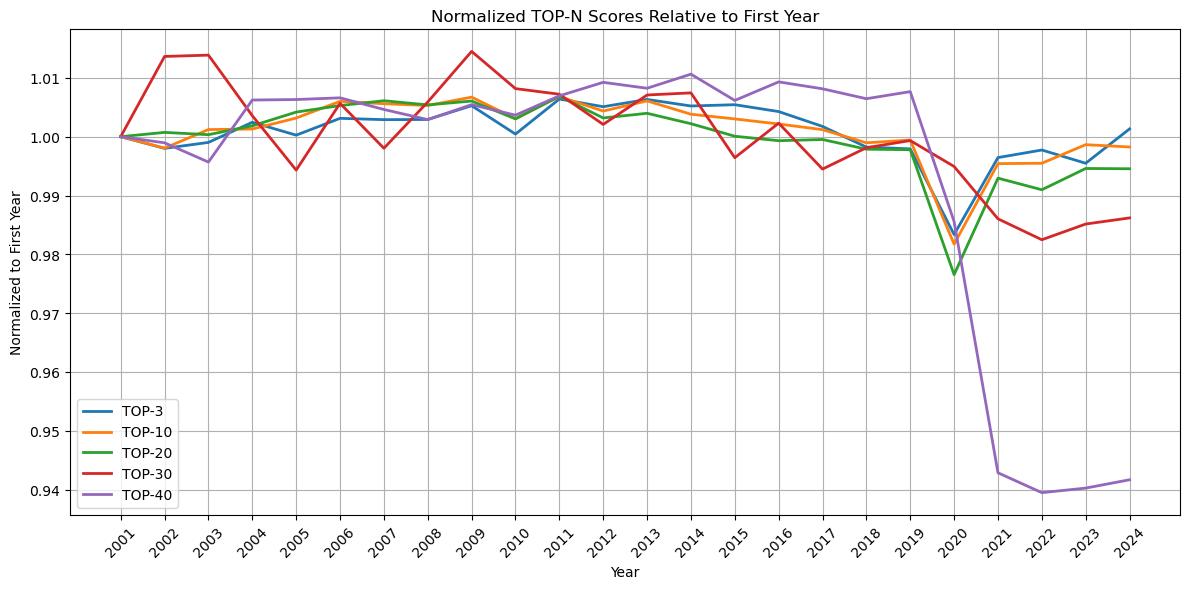

In [21]:
import matplotlib.pyplot as plt 
import pandas as pd 

top_entries_list = [3, 10, 20, 30, 40] 
normalized_stats_list = [] 

for n in top_entries_list: 
    # Collect top-N entries
    top_raw = hp.collect_top_entries(data, num_entries=n) 
    if top_raw.empty: 
        continue 
    
    # Compute mean TOP-N per year
    top_n_mean = top_raw.groupby("jahr")["iaaf_score"].mean().reset_index(name="top_mean") 
    
    # Normalize to first year
    first_year_value = top_n_mean["top_mean"].iloc[0] 
    top_n_mean["normalized"] = top_n_mean["top_mean"] / first_year_value 
    
    # Add a column with number of entries for legend
    top_n_mean["num_entries"] = n
    
    # Append to list
    normalized_stats_list.append(top_n_mean) 
    
# Plot normalized TOP-N scores
plt.figure(figsize=(12, 6)) 

for stats in normalized_stats_list: 
    plt.plot(stats["jahr"], stats["normalized"], label=f"TOP-{stats['num_entries'].iloc[0]}", linewidth=2) 

plt.xlabel("Year") 
plt.ylabel("Normalized to First Year") 
plt.title("Normalized TOP-N Scores Relative to First Year") 
plt.legend() 
plt.grid(True) 
plt.xticks(sorted(data["jahr"].unique()), rotation=45) 
plt.tight_layout() 
plt.show()


#### Interpretation

- We can see a clear drop in 2020 (Corona performances)
- Top 30 is decreasing more or less since 2014 (no Corona effect; Top Performances more affected?!)



### Looking at the overall density of performances e.g. the Standard deviation

Standard deviation is a good indicator of how dense a distribution is

- p-value -> tests the null hypothesis that the slope of the regression line is zero (e.g. no relationship)
- R^2 -> Explains how much of variation in dependent variable (e.g. std dev) is explained by independent variable (e.g. years) (Range 0: Dependent explains no variation; 1: Dependent explains all variation)

In the following, one can see the difference if normalization to the first year is done "within group" (mean in a discipline) and "in between group" (mean per year in relation to first year)

       jahr geschlecht altersklasse       disziplin  leistung  wind  \
0      2001          M           18           100 m     10.55  +0,3   
1      2001          M           18           100 m     10.61   NaN   
2      2001          M           18           100 m     10.73  +1,6   
3      2001          M           18           100 m     10.74  +0,9   
4      2001          M           18           100 m     10.76  +0,7   
...     ...        ...          ...             ...       ...   ...   
61445  2024          W          U23  Stabhochsprung      3.40   NaN   
61446  2024          W          U23  Stabhochsprung      3.40   NaN   
61447  2024          W          U23  Stabhochsprung      3.40   NaN   
61448  2024          W          U23  Stabhochsprung      3.40   NaN   
61449  2024          W          U23  Stabhochsprung      3.40   NaN   

                    name  geburtsjahr                   verein       datum  \
0            Till Helmke         1984  TSV Friedberg-Fauerbach      0

c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x0000024F49578FE0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)


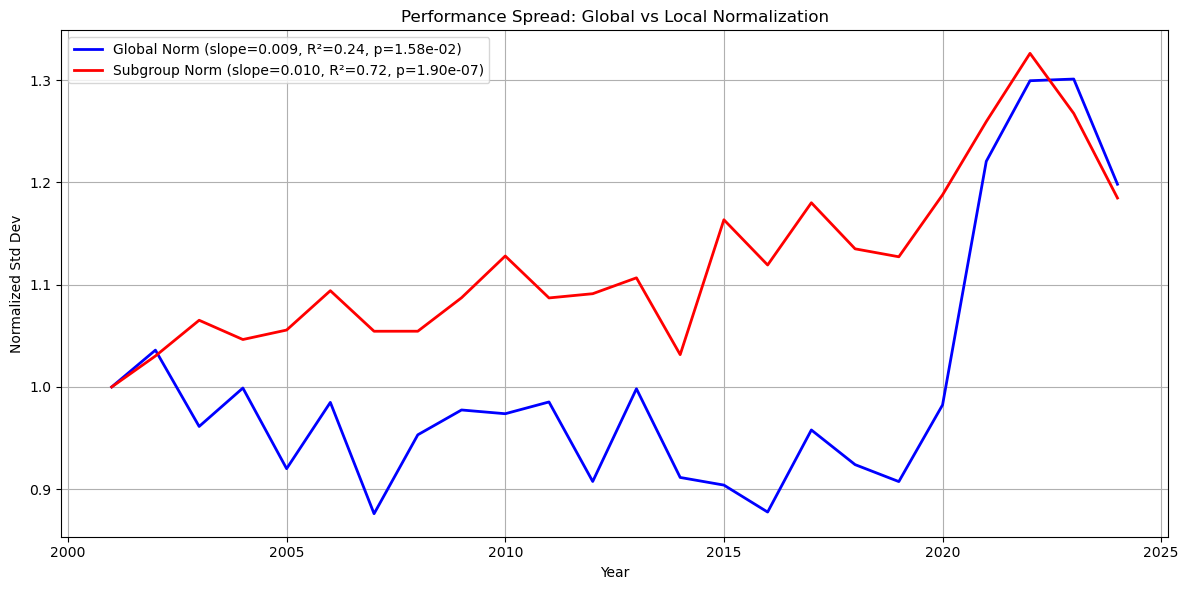

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm

# --- Global normalization ---
top_raw = hp.collect_top_entries(data, num_entries=50)

print(top_raw)

global_std = top_raw.groupby('jahr')['iaaf_score'].std()
global_std_norm = global_std / global_std.iloc[0]  # normalize to 2001

# Linear regression
X, model_global, slope_global, r2_global, p_global = hp.linear_regression(global_std_norm)

# --- local normalization
norm_data = hp.func_norm_per_group(top_raw, np.std)

X, model_local, slope_local, r2_local, p_local = hp.linear_regression(norm_data)

# --- 3. Plot ---
plt.figure(figsize=(12,6))
plt.plot(global_std_norm.index, global_std_norm.values, color='blue', linewidth=2,
         label=f'Global Norm (slope={slope_global:.3f}, R²={r2_global:.2f}, p={p_global:.2e})')
plt.plot(norm_data.index, norm_data.values, color='red', linewidth=2,
         label=f'Subgroup Norm (slope={slope_local:.3f}, R²={r2_local:.2f}, p={p_local:.2e})')
plt.xlabel("Year")
plt.ylabel("Normalized Std Dev")
plt.title("Performance Spread: Global vs Local Normalization")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### Interpretation

Standard deviation is clearly increasing -> drop in performance density

There clearly is an significant effect nevertheless if subgroup or global normalization. 

### Looking at age group, gender, discipline to find the disciplines that are struggling

1. Idea: Looking at the discipline groups; That is a division the DLV is doing (and makes sense to me)

2. Looking at gender

3. Looking at age groups x gender

To further exclude absolute performance differences all calculations are done with normalization in the subgroups (Especially in running e.g. longer distances the differences are naturally higher)


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x0000024F49578FE0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x0000024F49578FE0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x0000024F49578FE0

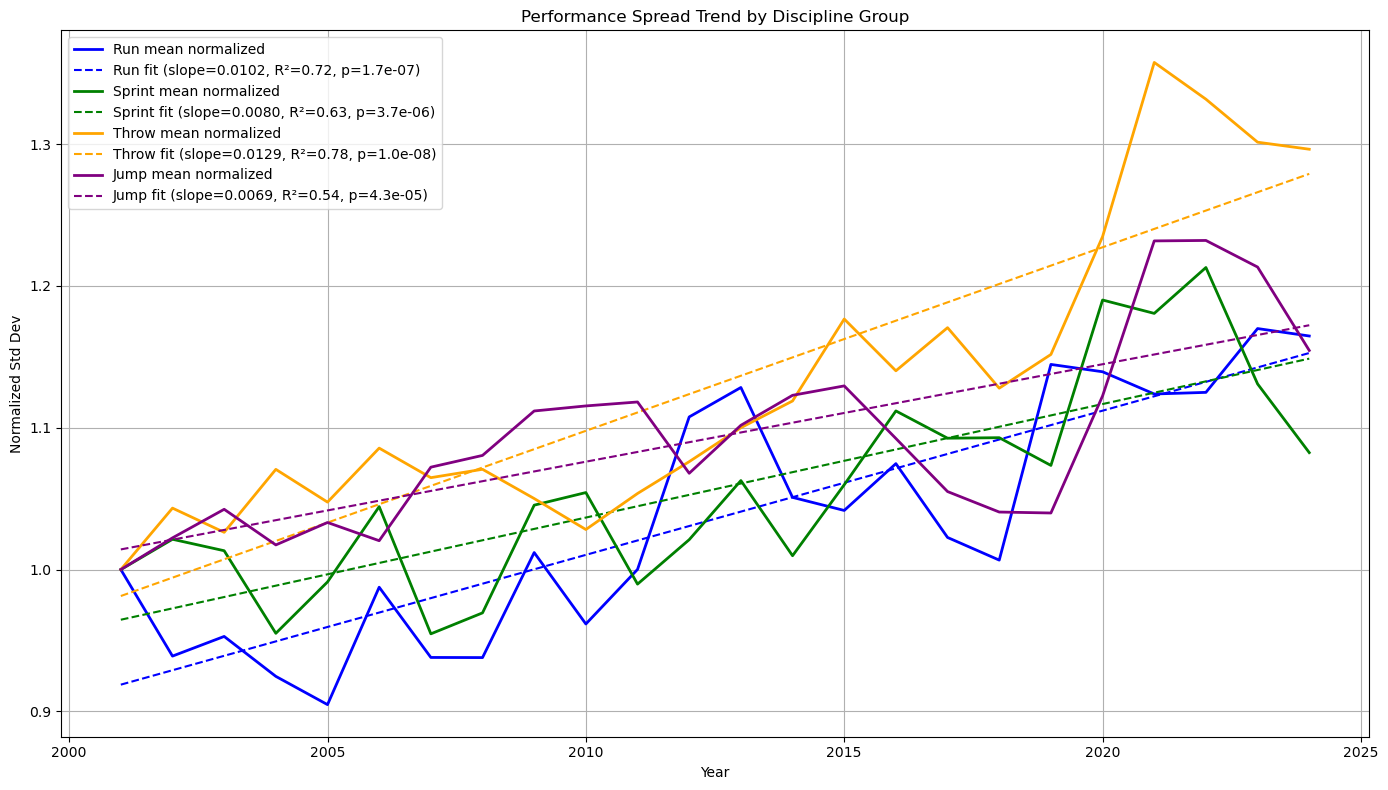

In [5]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

groups = {
    'Run': run_disciplines,
    'Sprint': sprint_disciplines,
    'Throw': throw_disciplines,
    'Jump': jump_disciplines
}

plt.figure(figsize=(14,8))

colors = {
    'Run': 'blue',
    'Sprint': 'green',
    'Throw': 'orange',
    'Jump': 'purple'
}

# Loop over discipline groups
for group_name, disciplines in groups.items():

    group_data = data[data['disziplin'].isin(disciplines)]

    mean_norm = hp.func_norm_per_group(group_data, np.std)
    
    X, model, slope, r2, p_value = hp.linear_regression(mean_norm)

    regression_line = model.predict(X)

    years = mean_norm.index.values.astype(float)

    # Plot mean normalized values
    plt.plot(years, mean_norm.values, color=colors[group_name], linewidth=2, label=f"{group_name} mean normalized")

    # Plot regression line
    plt.plot(years, regression_line, linestyle="--", color=colors[group_name], label=f"{group_name} fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")


plt.xlabel("Year")
plt.ylabel("Normalized Std Dev")
plt.title("Performance Spread Trend by Discipline Group")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x0000024F49578FE0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithC

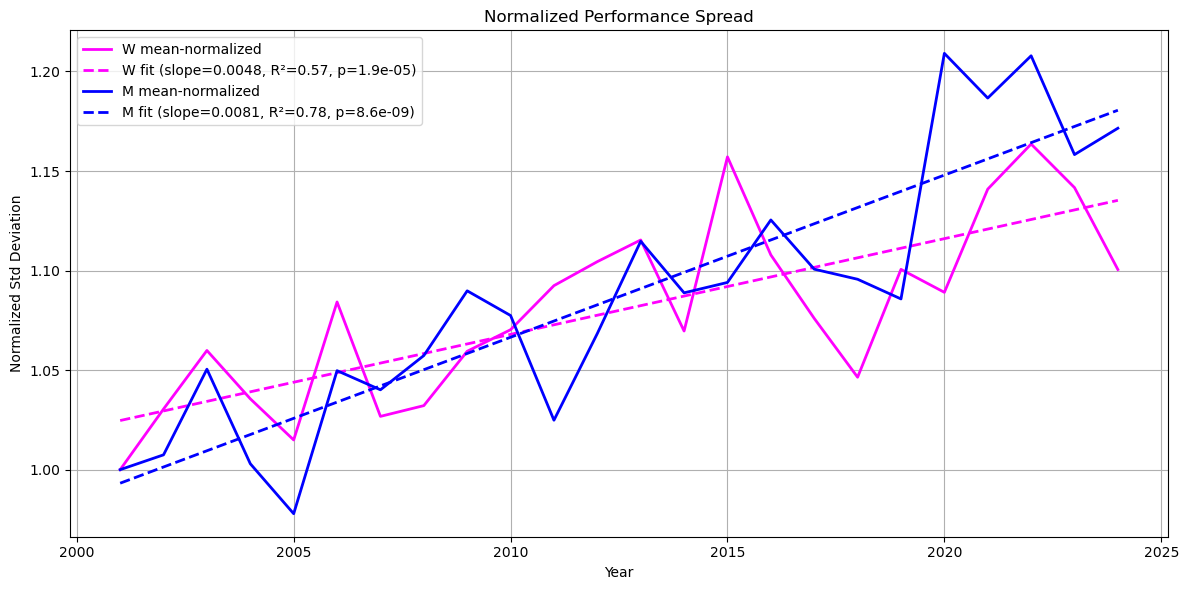

In [6]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

genders = ["W", "M"]
colors = {"W": "magenta", "M": "blue"}

plt.figure(figsize=(12, 6))

for gender in genders:
    
    gender_data = data[data["geschlecht"] == gender]

    #Get top 30 data
    gender_data = hp.collect_top_entries(gender_data, 30)

    norm_data_per_gender = hp.func_norm_per_group(gender_data, np.std)

    X, model, slope, r2, p_value = hp.linear_regression(norm_data_per_gender)

    regression_line = model.predict(X)

    years = mean_norm.index.values.astype(float)

    # normalized curve
    plt.plot(years, norm_data_per_gender.values, color=colors[gender], linewidth=2, label=f"{gender} mean-normalized")

    # Regression line
    plt.plot(years, regression_line, "--",color=colors[gender], linewidth=2, label=f"{gender} fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")


plt.xlabel("Year")
plt.ylabel("Normalized Std Deviation")
plt.title("Normalized Performance Spread")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x0000024F49578FE0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithC

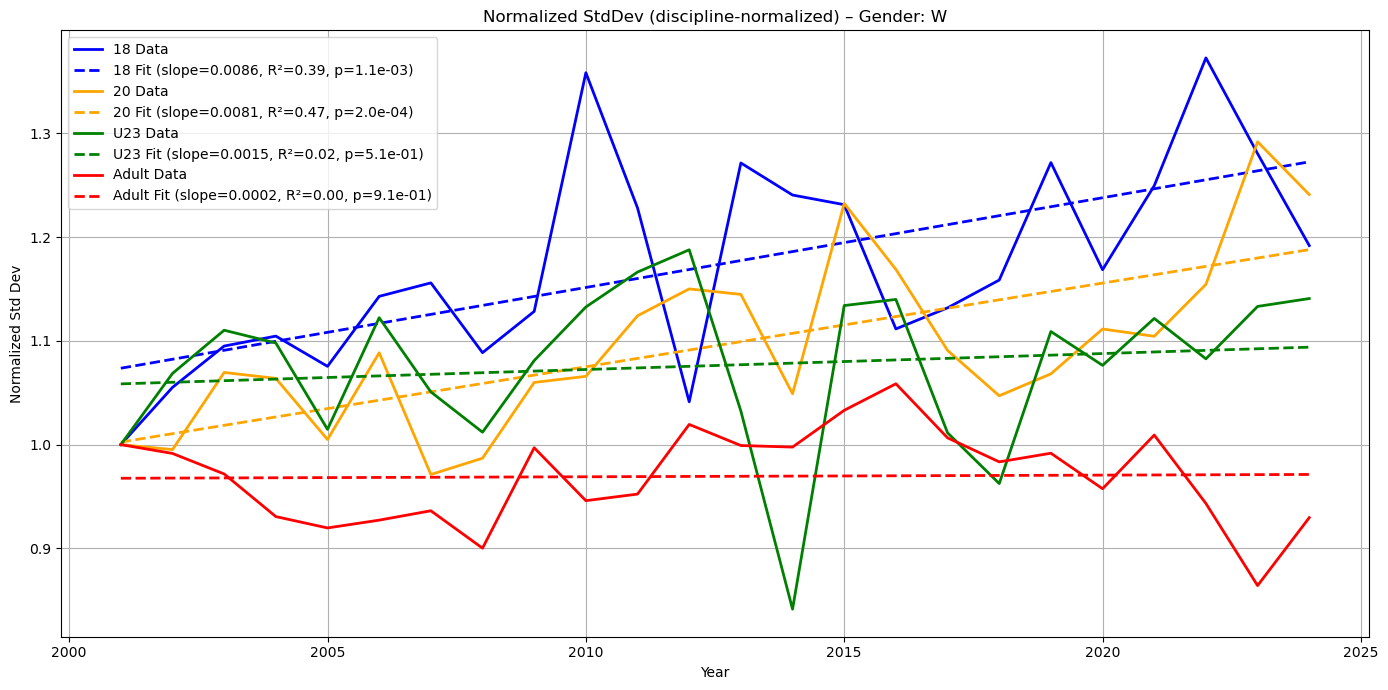

c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x0000024F49578FE0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithC

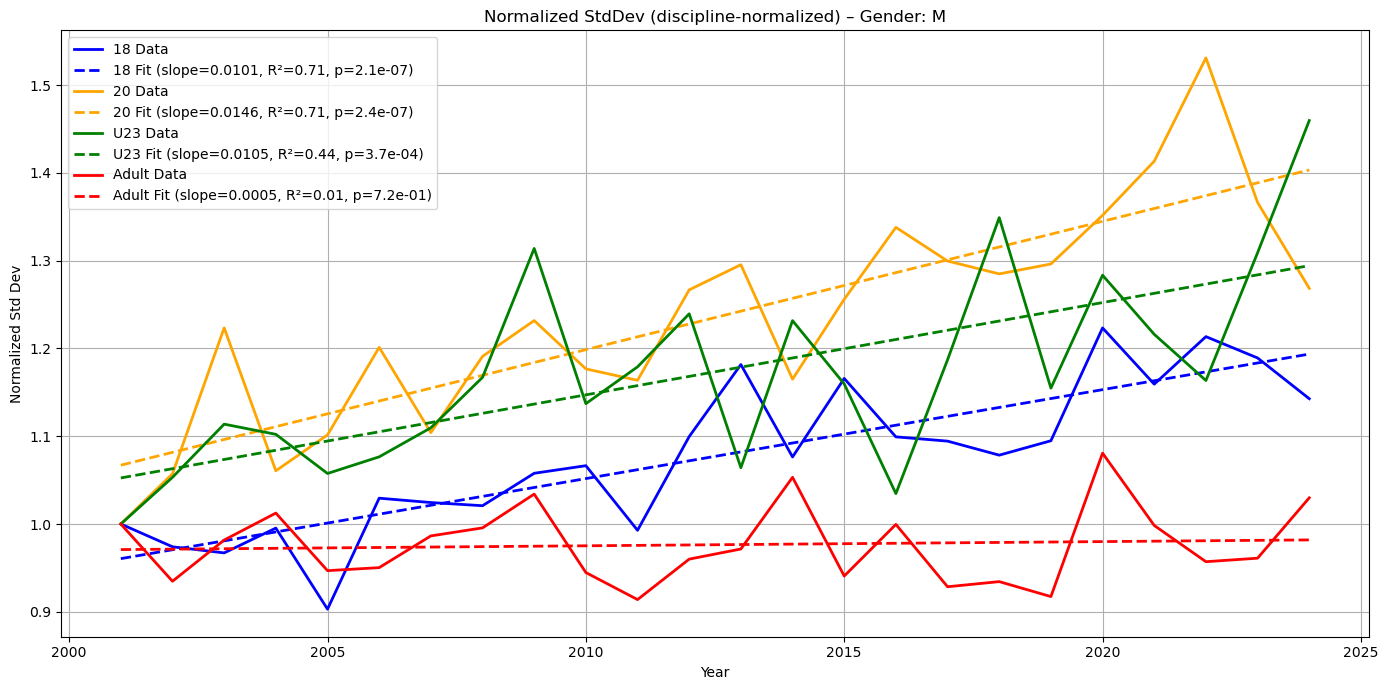

In [7]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

genders = ['W', 'M']
age_groups = ['18', '20', 'U23', 'Adult']

age_colors = {
    '18': 'blue',
    '20': 'orange',
    'U23': 'green',
    'Adult': 'red'
}

for gender in genders:
    plt.figure(figsize=(14,7))

    for age in age_groups:

        # Fix adult naming
        if age == "Adult":
            age_filter = "Frauen" if gender == "W" else "Maenner"
        else:
            age_filter = age

        # Filter to this gender × age
        base_group = data[(data["geschlecht"] == gender) &(data["altersklasse"] == age_filter)]

        base_group = hp.collect_top_entries(base_group, 30)

        mean_norm = hp.func_norm_per_group(base_group, np.std)

        years = mean_norm.index.values.astype(float)
        vals = mean_norm.values

        X, model, slope, r2, p_value = hp.linear_regression(mean_norm)

        regression_line = model.predict(X)

        plt.plot(years, vals, linestyle='-', color=age_colors[age], linewidth=2, label=f"{age} Data")

        plt.plot(years, regression_line, linestyle='--', color=age_colors[age], linewidth=2, label=f"{age} Fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")

    plt.title(f"Normalized StdDev (discipline-normalized) – Gender: {gender}")
    plt.xlabel("Year")
    plt.ylabel("Normalized Std Dev")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


#### Interpretation

We can see the trend to higher std. in nearly all distributions tested. Key takeaways:

1. Decrease in density in running is highest
2. Decrease in density is higher in men than in woman
3. Adult data is more or less stable, but age groups are diverging

#### Where does the higher standard deviation come from?

-> It can be, that top performances are getting better, but not the rest or the other way around; the top performances are stable, but the rest is getting weaker 

1. What is "top"? Is this discipline individual? Is there a way to define top based on top 30?
2. Which positions are driving the increase in variability?

#### Which "Rank" is contributing "how much" to the variance?

1. Relative contribution: How much is rank 30 in year x differing to baseline year 2001 (Also done within every group  discipline x age group x gender) 

r = rank
g = group (discipline x age group x gender)
S = IAAF Score
y = year

S_rel = S_(g,r)(y) / S_(g,r)(y=2001)

-> removing differences in scales across gender, disciplines

2. Averaging across the subgroups 

mu_r(y) = 1/ num_groups sum over all groups of S_rel_(g,r)(y)

3. Calculating derivation from top 1 rank

diff_r(y) = mu_r(y) - mu_1(y)

This is done to see if a rank is evolving faster or slower than the top performance rank -> difference from the top, competitive spread calculation

We will plot this:

if diff_r(y) is lower than 0 -> diff is lagging behind

4. Square and get fractional contribution of each rank to the total deviation per year

var_r(y) =  diff_r(y) ^2

var_total(y) = sum_r=1to30 var_r(y)

frac_r(y) = var_r(y)/var_total(y)

This is done so we can see how much of the total spread away from the winner is caused by rank r?

Higher ranks (close to 1) usually contribute little; deep ranks dominate variance when the field stretches.

Also we can state, that if lower ranks contribute more, the performance is widening. One might ask "But when we square, we dont know if ranks are improving or declining more than rank 1?" -> That's not the case: They are declining more, because the variance is dependend of rank 1: If a low rank is improving more than rank 1, it would mean it is getting closer to rank 1 -> the variance would be lower -> The contribution is lower. if low ranks catch up, their contribution gets lower. If they fall behind, their contribution grows.

Answering: Who contributes how much to inequality of improvement?

C:\Users\Mattis\AppData\Local\Temp\ipykernel_17912\2612516215.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('RdYlGn_r', top_n)  # rank 1=green, rank 30=red


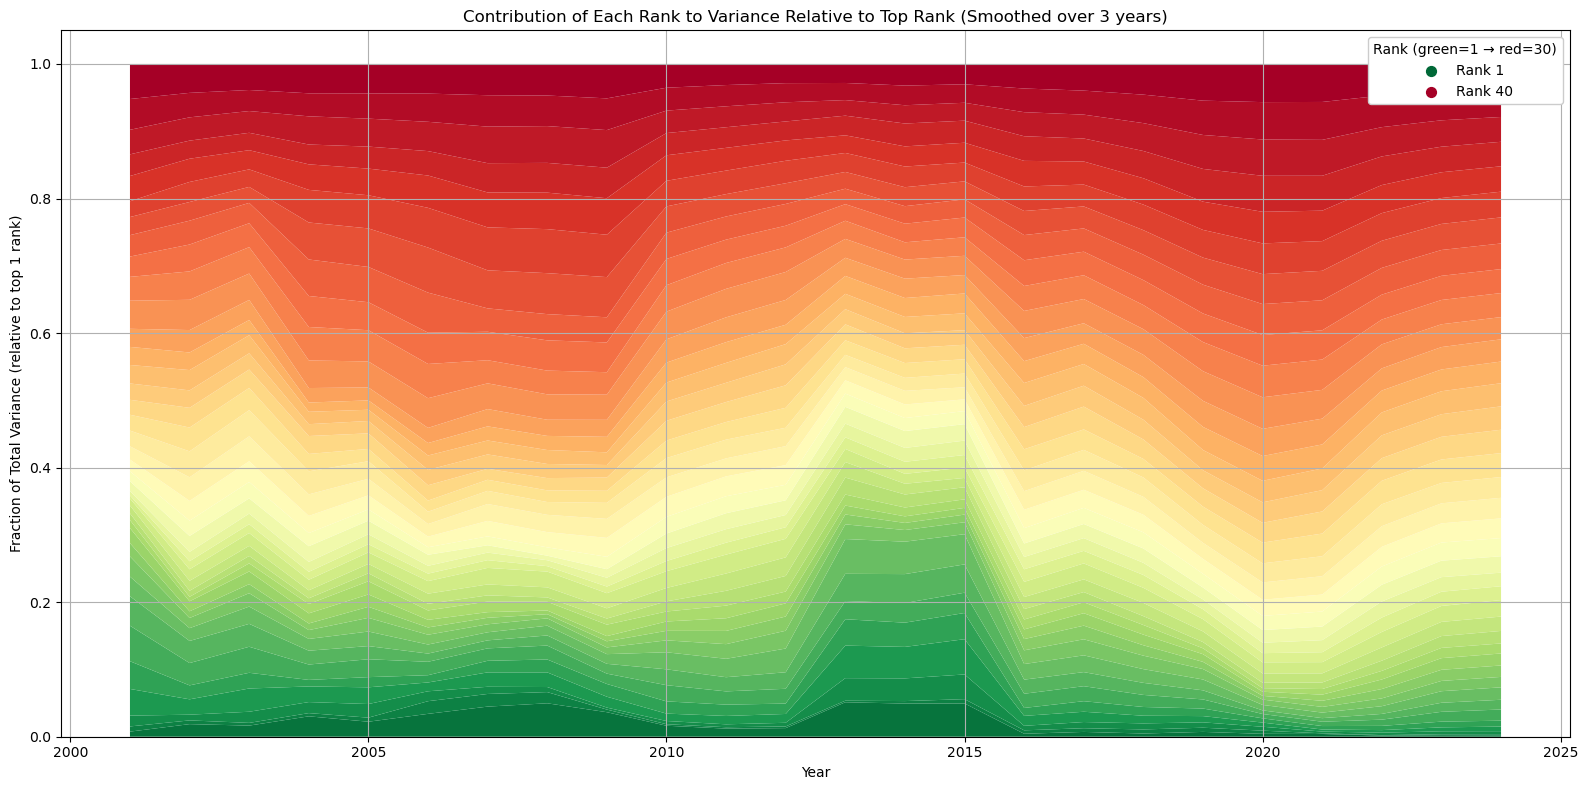

C:\Users\Mattis\AppData\Local\Temp\ipykernel_17912\2612516215.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('RdYlGn_r', top_n)


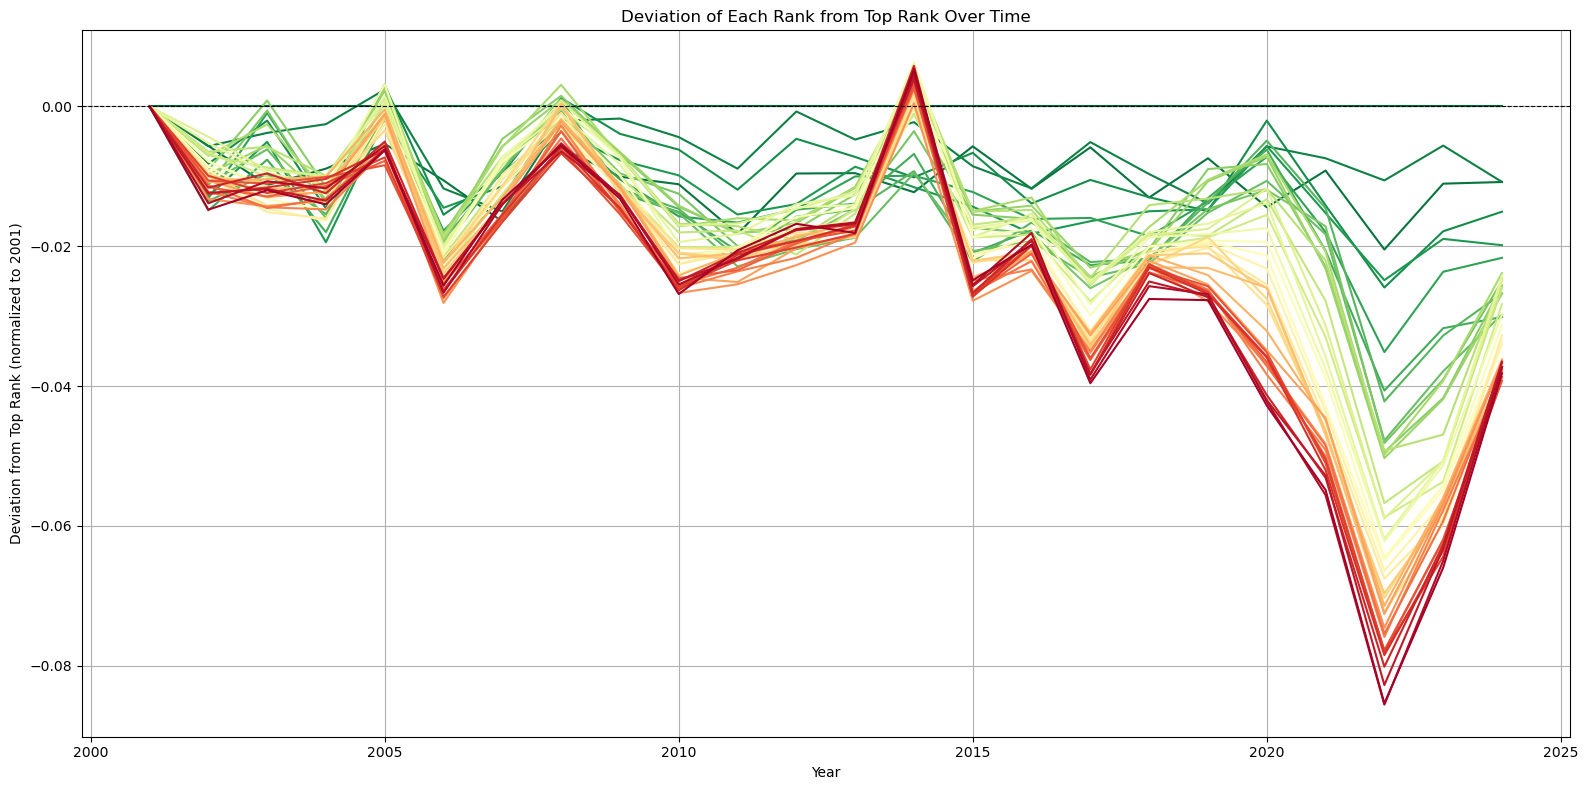

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

top_n = 40
years = sorted(data['jahr'].unique())

# 1. Collect normalized scores per rank per subgroup
S_rel_gr_list = {r: [] for r in range(1, top_n+1)}

for (disc, gender, age), subdata in top_raw.groupby(["disziplin","geschlecht","altersklasse"]):
    S_g = subdata.groupby("jahr")["iaaf_score"].apply(
        lambda x: x.sort_values(ascending=False).head(top_n).values
    )
    
    if 2001 not in S_g.index:
        continue

    S_gr = pd.DataFrame({year: vals for year, vals in zip(S_g.index, S_g.values)}).T
    S_gr.columns = range(1, top_n+1)
    S_gr.index.name = "jahr"

    # Normalize to 2001
    S_rel_gr = S_gr / S_gr.loc[2001]

    # Store per rank
    for r in range(1, top_n+1):
        S_rel_gr_list[r].append(S_rel_gr[r])


# Compute mean per rank across subgroups
mu_r = pd.DataFrame({r: pd.concat(series, axis=1).mean(axis=1) 
                                   for r, series in S_rel_gr_list.items()})
mu_r = mu_r.sort_index()

# Compute fraction of total variance per rank **relative to top rank**
diff_r = mu_r.subtract(mu_r[1], axis=0)  # rank 1 as reference

var_r = diff_r**2
total_var = var_r.sum(axis=1)

frac_var_r = var_r.div(total_var, axis=0)

# --- Optional: smooth over 3 years ---
frac_var_r_smooth = frac_var_r.rolling(window=3, min_periods=1, center=True).mean()

# 4. Plot stacked area chart for all 30 ranks
plt.figure(figsize=(16,8))
colors = plt.cm.get_cmap('RdYlGn_r', top_n)  # rank 1=green, rank 30=red


plt.stackplot(frac_var_r_smooth.index, frac_var_r_smooth.T, colors=[colors(i) for i in range(top_n)])
plt.xlabel("Year")
plt.ylabel("Fraction of Total Variance (relative to top 1 rank)")
plt.title("Contribution of Each Rank to Variance Relative to Top Rank (Smoothed over 3 years)")
plt.grid(True)
# Add a dot gradient legend
for i in range(top_n):
    plt.scatter([], [], color=colors(i), s=50, label=f'Rank {i+1}' if i in [0, top_n-1] else "_nolegend_")

plt.legend(loc='upper right', title='Rank (green=1 → red=30)', framealpha=1)
plt.tight_layout()
plt.show()
# 5. Plot deviations from top rank over time
plt.figure(figsize=(16,8))
colors = plt.cm.get_cmap('RdYlGn_r', top_n)

for r in range(1, top_n+1):
    plt.plot(diff_r.index, diff_r[r], color=colors(r-1), label=f"Rank {r}")

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Deviation from Top Rank (normalized to 2001)")
plt.title("Deviation of Each Rank from Top Rank Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()



In [9]:
percent_change_all = (mu_r.loc[2024] - mu_r.loc[2001]) / mu_r.loc[2001] * 100
print(percent_change_all)

1     2.084128
2     1.003576
3     1.004891
4     0.578572
5     0.099265
6    -0.081248
7    -0.928375
8    -0.590184
9    -0.893481
10   -0.412081
11   -0.475156
12   -0.595035
13   -0.298818
14   -0.379068
15   -0.509767
16   -0.743463
17   -0.403850
18   -0.337827
19   -0.891754
20   -1.046965
21   -1.271695
22   -1.311160
23   -1.192890
24   -1.664089
25   -1.734853
26   -1.684612
27   -1.716709
28   -1.532486
29   -1.591566
30   -1.561283
dtype: float64


As we can see, the **contribution to the variance is getting larger for lower ranks** -> They are falling behind relative to the top

Plot 2 Shows that also ~2005 the lower ranks are getting closer and improving towards the top 1, but afterwards genually falling behind

# Doing the same, but for global standard deviation

For more interpretability

So taking the std for the groups that are researched;

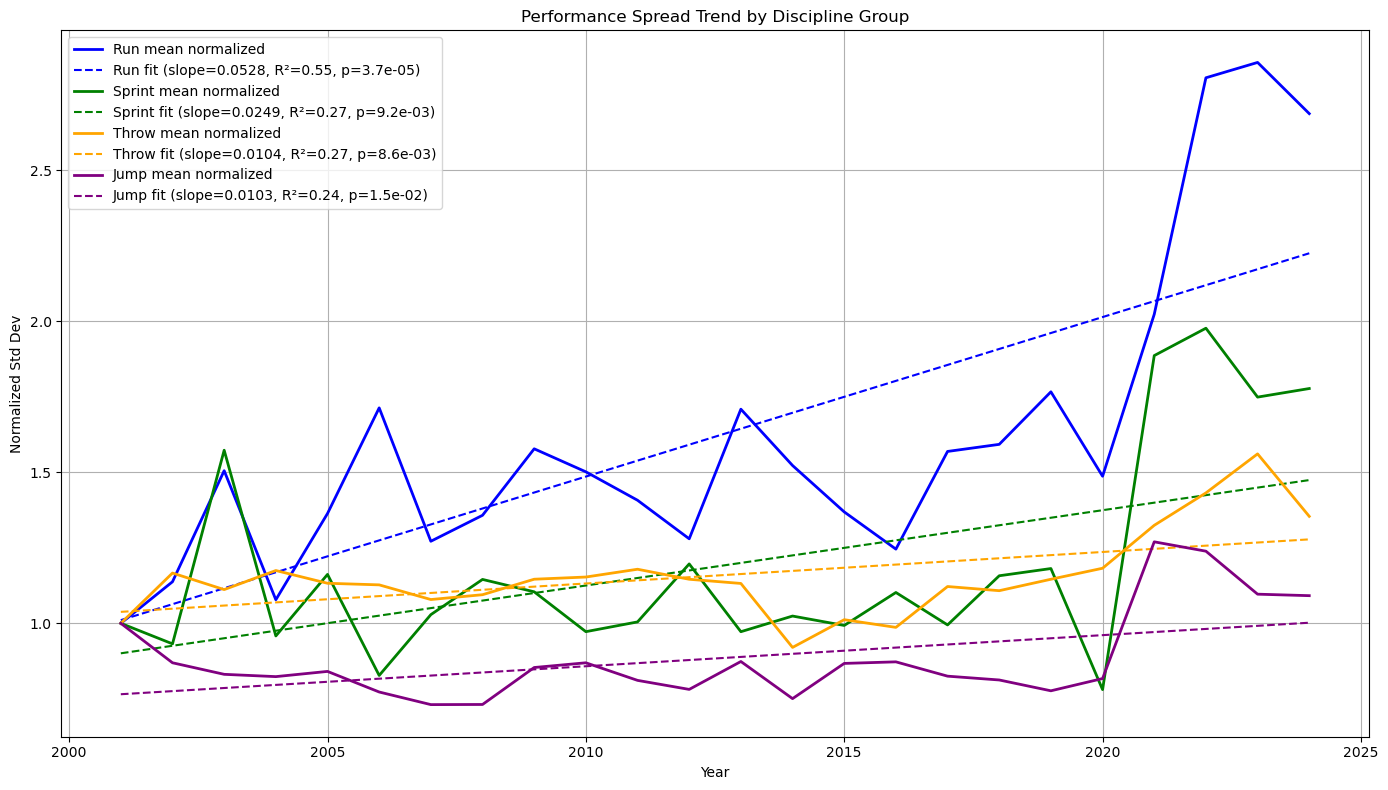

In [24]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

groups = {
    'Run': run_disciplines,
    'Sprint': sprint_disciplines,
    'Throw': throw_disciplines,
    'Jump': jump_disciplines
}

plt.figure(figsize=(14,8))

colors = {
    'Run': 'blue',
    'Sprint': 'green',
    'Throw': 'orange',
    'Jump': 'purple'
}

# Loop over discipline groups
for group_name, disciplines in groups.items():

    group_data = top_raw[top_raw['disziplin'].isin(disciplines)]

    global_std = group_data.groupby('jahr')['iaaf_score'].std()
    global_std_norm = global_std / global_std.iloc[0]
    
    X, model, slope, r2, p_value = hp.linear_regression(global_std_norm)

    regression_line = model.predict(X)

    years = global_std_norm.index.values.astype(float)

    # Plot mean normalized values
    plt.plot(years, global_std_norm.values, color=colors[group_name], linewidth=2, label=f"{group_name} mean normalized")

    # Plot regression line
    plt.plot(years, regression_line, linestyle="--", color=colors[group_name], label=f"{group_name} fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")


plt.xlabel("Year")
plt.ylabel("Normalized Std Dev")
plt.title("Performance Spread Trend by Discipline Group")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")


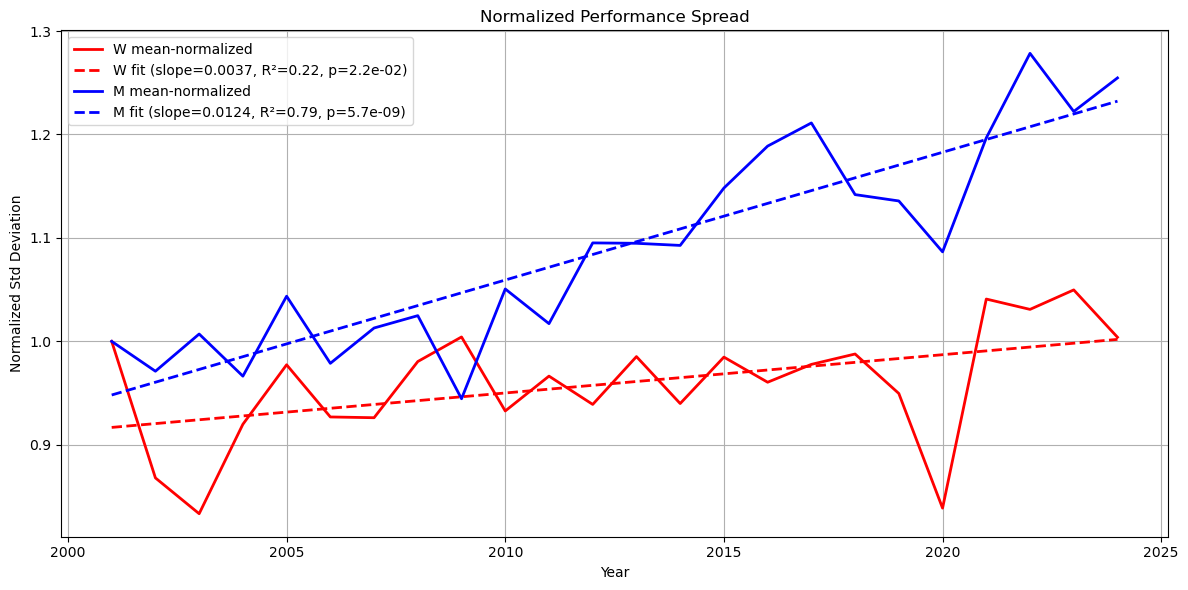

In [25]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

genders = ["W", "M"]
colors = {"W": "red", "M": "blue"}

plt.figure(figsize=(12, 6))

for gender in genders:
    
    gender_data = data[data["geschlecht"] == gender]

    #Get top 30 data
    gender_data = hp.collect_top_entries(gender_data, 30)

    global_std = gender_data.groupby('jahr')['iaaf_score'].std()
    global_std_norm = global_std / global_std.iloc[0]

    X, model, slope, r2, p_value = hp.linear_regression(global_std_norm)

    regression_line = model.predict(X)

    years = global_std_norm.index.values.astype(float)
    # normalized curve
    plt.plot(years, global_std_norm.values, color=colors[gender], linewidth=2, label=f"{gender} mean-normalized")

    # Regression line
    plt.plot(years, regression_line, "--",color=colors[gender], linewidth=2, label=f"{gender} fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")


plt.xlabel("Year")
plt.ylabel("Normalized Std Deviation")
plt.title("Normalized Performance Spread")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Lite

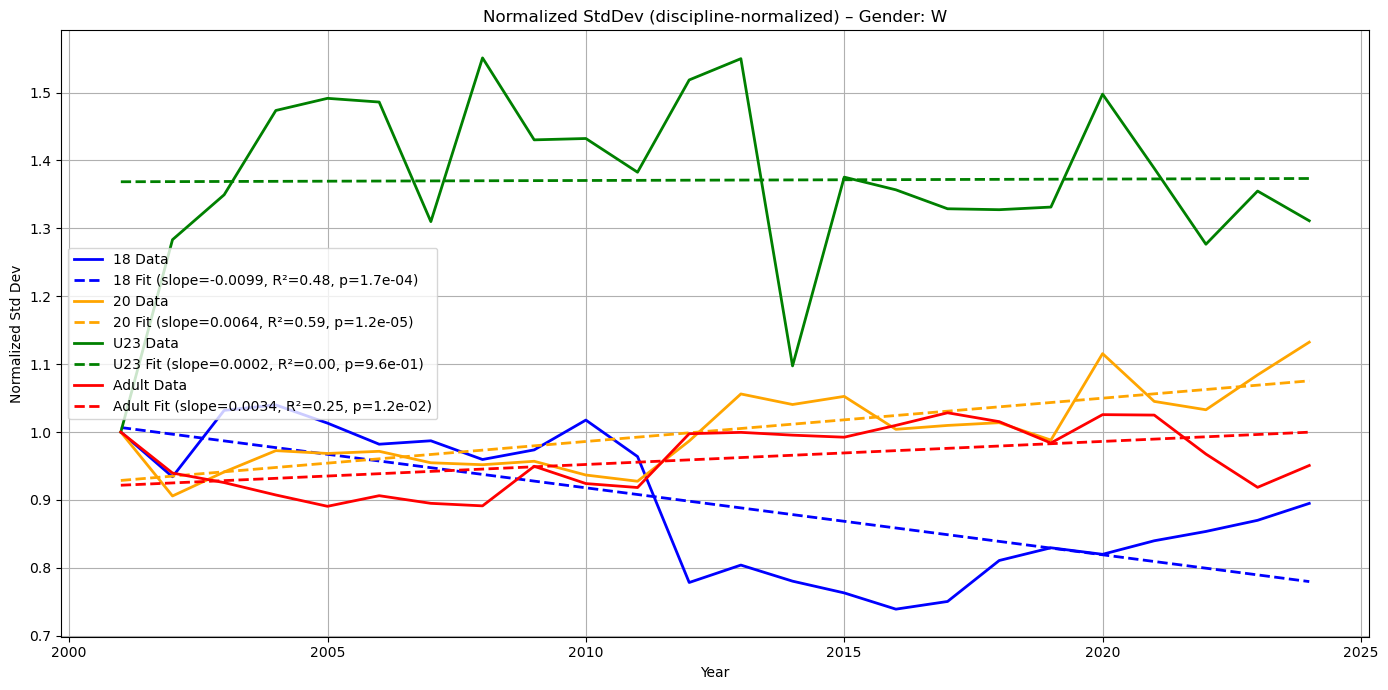

c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Lite

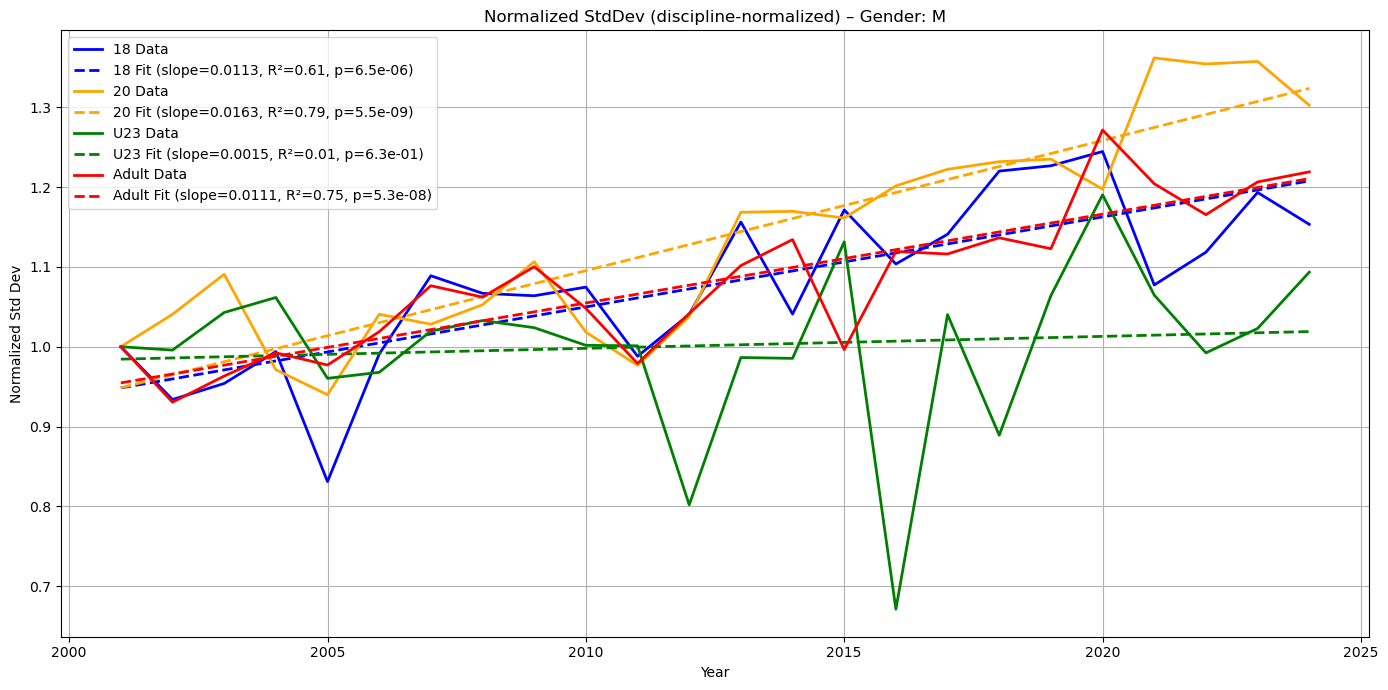

In [26]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

genders = ['W', 'M']
age_groups = ['18', '20', 'U23', 'Adult']

age_colors = {
    '18': 'blue',
    '20': 'orange',
    'U23': 'green',
    'Adult': 'red'
}

for gender in genders:
    plt.figure(figsize=(14,7))

    for age in age_groups:

        # Fix adult naming
        if age == "Adult":
            age_filter = "Frauen" if gender == "W" else "Maenner"
        else:
            age_filter = age

        # Filter to this gender × age
        base_group = data[(data["geschlecht"] == gender) &(data["altersklasse"] == age_filter)]

        base_group = hp.collect_top_entries(base_group, 30)

        global_std = base_group.groupby('jahr')['iaaf_score'].std()
        global_std_norm = global_std / global_std.iloc[0]

        X, model, slope, r2, p_value = hp.linear_regression(global_std_norm)

        regression_line = model.predict(X)

        years = global_std_norm.index.values.astype(float)
        vals = global_std_norm.values

        plt.plot(years, vals, linestyle='-', color=age_colors[age], linewidth=2, label=f"{age} Data")

        plt.plot(years, regression_line, linestyle='--', color=age_colors[age], linewidth=2, label=f"{age} Fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")

    plt.title(f"Normalized StdDev (discipline-normalized) – Gender: {gender}")
    plt.xlabel("Year")
    plt.ylabel("Normalized Std Dev")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


       1         2         3         4          5          6          7   \
jahr                                                                       
2001  0.0  2.468448  4.869416  6.294958   7.349762   8.440954   9.220947   
2002  0.0  3.275528  5.547520  7.421287   9.009041  10.065175  10.887198   
2003  0.0  3.925698  5.886292  7.294614   8.781156   9.578328  10.936583   
2004  0.0  3.443331  5.638314  8.135882   9.662625  10.294189  11.418901   
2005  0.0  2.902605  4.818651  6.229187   7.686375   8.789554   9.750225   
2006  0.0  3.503370  6.404172  8.035044   9.130772  10.607409  11.772539   
2007  0.0  3.709579  6.187921  7.247142   8.401483   9.451277  10.373466   
2008  0.0  3.188681  5.305816  6.488465   7.886085   8.936814   9.503052   
2009  0.0  3.242310  5.041605  6.764336   8.217313   9.632634  10.554585   
2010  0.0  3.404662  5.206192  6.834235   8.238461   9.722492  10.407941   
2011  0.0  4.142848  6.385840  8.199764   9.598731  10.617345  11.731016   
2012  0.0  3

C:\Users\Mattis\AppData\Local\Temp\ipykernel_17912\3354724206.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('RdYlGn_r', top_n)  # rank 1=green, rank 30=red


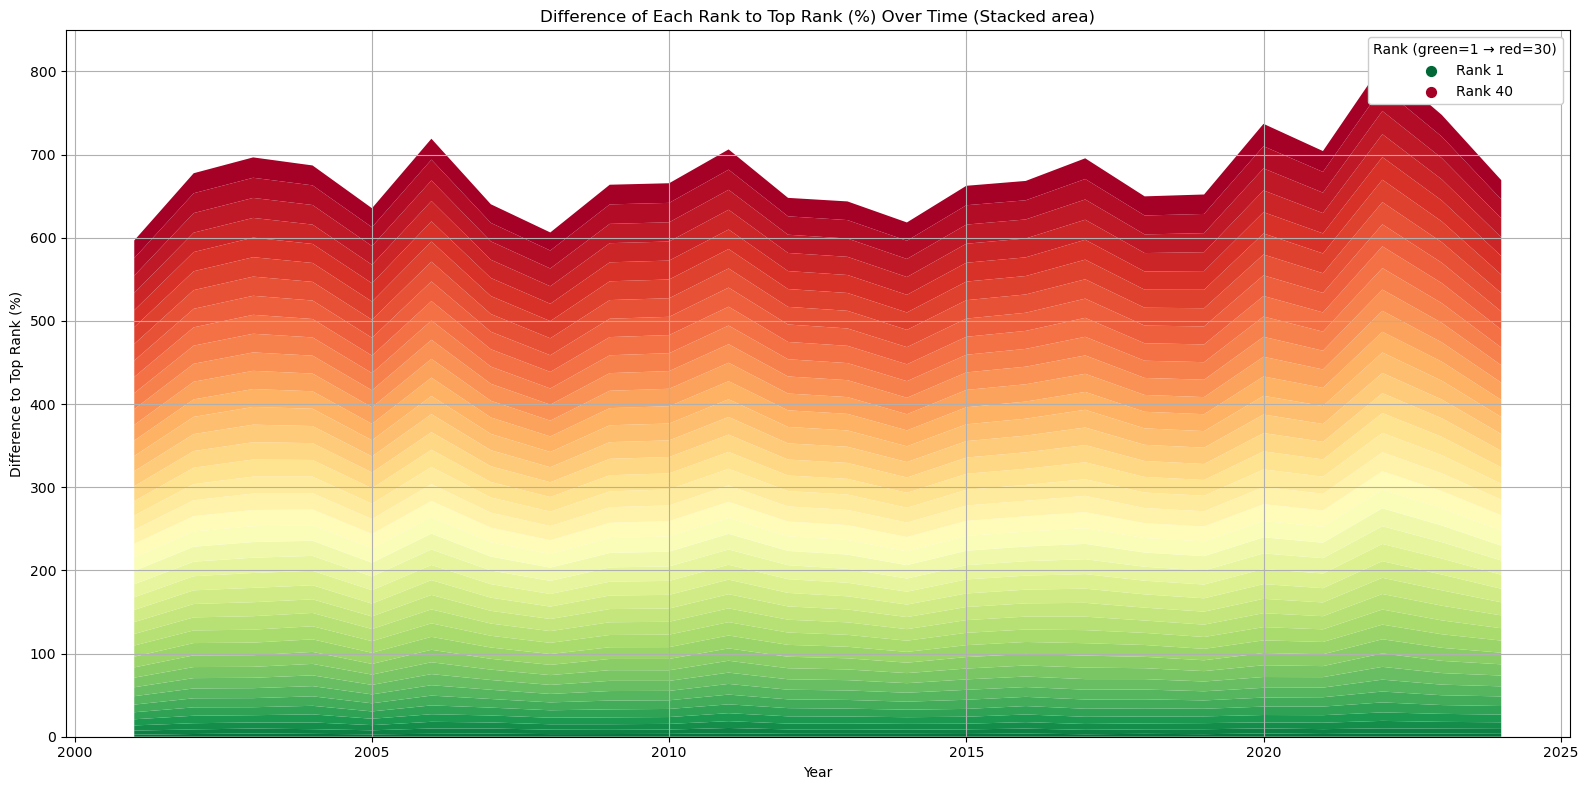

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

top_n = 40
years = sorted(data['jahr'].unique())

# 1. Collect normalized scores per rank per subgroup
S_rel_gr_list = {r: [] for r in range(1, top_n+1)}

for (disc, gender, age), subdata in top_raw.groupby(["disziplin","geschlecht","altersklasse"]):
    S_g = subdata.groupby("jahr")["iaaf_score"].apply(
        lambda x: x.sort_values(ascending=False).head(top_n).values
    )
    
    if 2001 not in S_g.index:
        continue

    S_gr = pd.DataFrame({year: vals for year, vals in zip(S_g.index, S_g.values)}).T
    S_gr.columns = range(1, top_n+1)
    S_gr.index.name = "jahr"

    diff_1_r = (S_gr[1].values[:, None] - S_gr) / S_gr[1].values[:, None] * 100
    diff_1_r[1] = 0

    # Store per rank
    for r in range(1, top_n+1):
        S_rel_gr_list[r].append(diff_1_r[r])


mu_r = pd.DataFrame({r: pd.concat(series, axis=1).mean(axis=1) 
                                   for r, series in S_rel_gr_list.items()})
mu_r = mu_r.sort_index()

print(mu_r)
plt.figure(figsize=(16,8))
colors = plt.cm.get_cmap('RdYlGn_r', top_n)  # rank 1=green, rank 30=red


plt.stackplot(mu_r.index, mu_r.T, colors=[colors(i) for i in range(top_n)])
plt.xlabel("Year")
plt.ylabel("Difference to Top Rank (%)")
plt.title("Difference of Each Rank to Top Rank (%) Over Time (Stacked area)")
plt.grid(True)
for i in range(top_n):
    plt.scatter([], [], color=colors(i), s=50, label=f'Rank {i+1}' if i in [0, top_n-1] else "_nolegend_")

plt.legend(loc='upper right', title='Rank (green=1 → red=30)', framealpha=1)
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
import statsmodels.api as sm

# Prepare a list to store results
results_list = []

years_numeric = mu_r.index.values  # x-axis

for r in range(1, top_n+1):
    y = mu_r[r].values
    X = sm.add_constant(years_numeric)  # adds intercept term
    model = sm.OLS(y, X).fit()
    
    # Extract results
    intercept, slope = model.params
    r2 = model.rsquared
    p_value = model.pvalues[1]  # p-value for slope
    
    results_list.append({
        'Rank': r,
        'Slope': slope,
        'Intercept': intercept,
        'R2': r2,
        'p_value': p_value
    })

# Convert list of dicts to DataFrame
regression_results = pd.DataFrame(results_list)
regression_results['Rank'] = regression_results['Rank'].astype(int)

print(regression_results)


    Rank     Slope   Intercept        R2   p_value
0      1  0.000000    0.000000       NaN       NaN
1      2  0.017852  -32.478156  0.109299  0.114588
2      3  0.019360  -33.335173  0.089698  0.155091
3      4  0.040739  -74.640065  0.183101  0.036986
4      5  0.037490  -66.758622  0.144719  0.066680
5      6  0.047372  -85.501066  0.200406  0.028264
6      7  0.054449  -98.753870  0.197531  0.029561
7      8  0.049545  -88.006335  0.153864  0.057980
8      9  0.068752 -125.854217  0.242811  0.014429
9     10  0.064610 -116.759751  0.208248  0.024998
10    11  0.065540 -117.980984  0.188213  0.034171
11    12  0.058643 -103.495905  0.145659  0.065729
12    13  0.054639  -94.908907  0.121440  0.095146
13    14  0.060874 -106.897223  0.142469  0.069011
14    15  0.068360 -121.423833  0.164242  0.049455
15    16  0.075549 -135.434472  0.188740  0.033892
16    17  0.073074 -130.005482  0.172062  0.043855
17    18  0.075587 -134.605480  0.167313  0.047178
18    19  0.079004 -141.116455 

c:\Users\Mattis\miniconda3\envs\bestenliste\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Average mu_r 2001-2004:
 1      0.000000
2      3.278251
3      5.485386
4      7.286685
5      8.700646
6      9.594661
7     10.615907
8     11.548422
9     12.151702
10    12.953997
11    13.704137
12    14.475679
13    14.977011
14    15.451604
15    15.889026
16    16.310122
17    16.870091
18    17.344472
19    17.737399
20    18.074329
21    18.425299
22    18.832579
23    19.179823
24    19.452570
25    19.692452
26    20.007976
27    20.291682
28    20.535615
29    20.803030
30    21.044109
31    21.353862
32    21.597614
33    21.777976
34    21.981945
35    22.240343
36    22.488008
37    22.744723
38    23.002623
39    23.205389
40    23.447642
dtype: float64

Average mu_r 2022-2024:
 1      0.000000
2      3.766642
3      5.947078
4      8.388963
5      9.686742
6     10.964664
7     12.158737
8     13.040813
9     14.100054
10    14.780289
11    15.555495
12    16.152076
13    16.560389
14    17.257953
15    17.887827
16    18.422941
17    18.916041
18    19.406640
19    

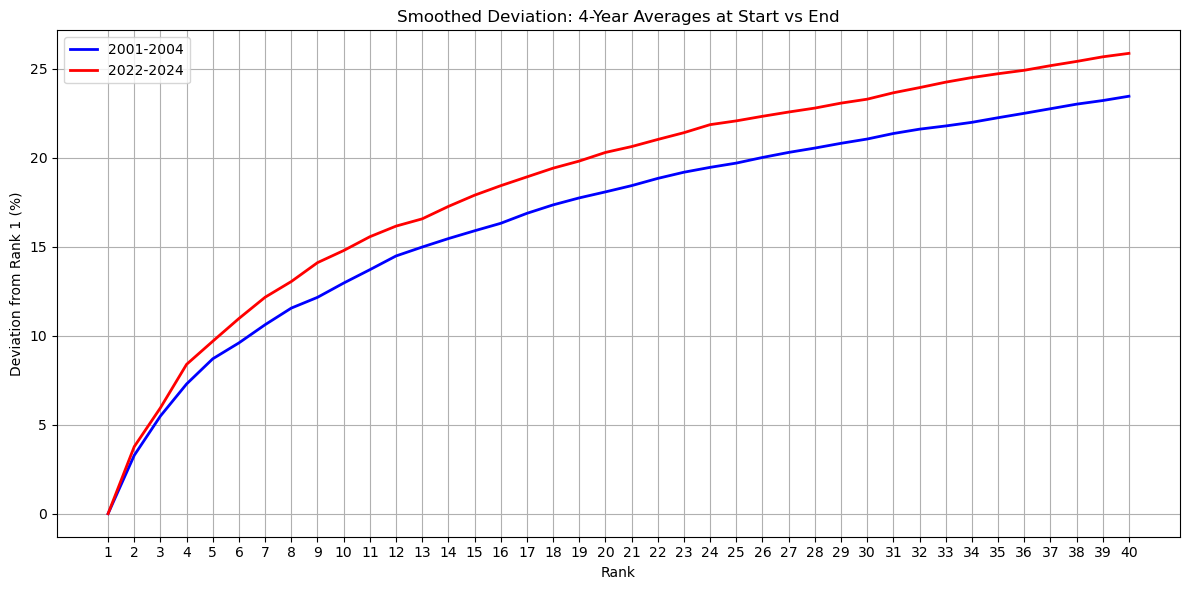

In [29]:
# Average over first 3 years
start_avg = mu_r.loc[2001:2004].mean()

# Average over last 3 years
end_avg = mu_r.loc[2022:2024].mean()

# Difference (end - start)
diff_avg = start_avg - end_avg

print("Average mu_r 2001-2004:\n", start_avg)
print("\nAverage mu_r 2022-2024:\n", end_avg)
print("\nDifference (2001-2003 minus 2022-2024):\n", diff_avg)

ranks = range(1, top_n + 1)

plt.figure(figsize=(12,6))
plt.plot(ranks, start_avg, label='2001-2004', color='blue', linewidth=2)
plt.plot(ranks, end_avg, label='2022-2024', color='red', linewidth=2)

plt.xlabel("Rank")
plt.ylabel("Deviation from Rank 1 (%)")
plt.title("Smoothed Deviation: 4-Year Averages at Start vs End")
plt.xticks(ranks)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



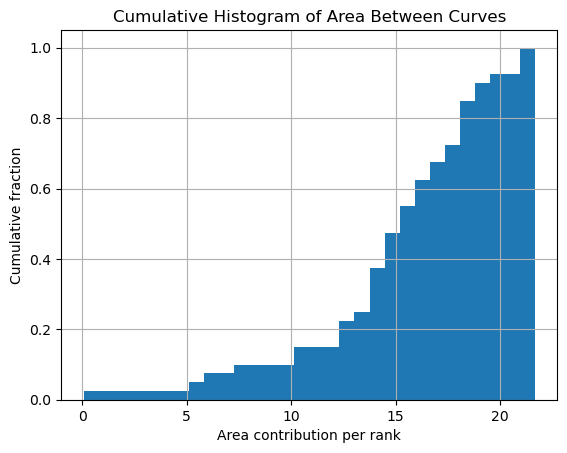

In [42]:
area_per_rank = np.abs(start_avg.values - end_avg.values)
cumulative_area = np.cumsum(area_per_rank)

plt.hist(
    area_per_rank,
    bins=30,
    cumulative=True,
    density=True
)
plt.xlabel("Area contribution per rank")
plt.ylabel("Cumulative fraction")
plt.title("Cumulative Histogram of Area Between Curves")
plt.grid(True)
plt.show()


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Lite

  Gender    Age  MeanDiff
0      W     18  1.773937
1      W     20  2.395688
2      W  Adult -1.778880
3      M     18  4.185757
4      M     20  3.853011
5      M  Adult  0.564434


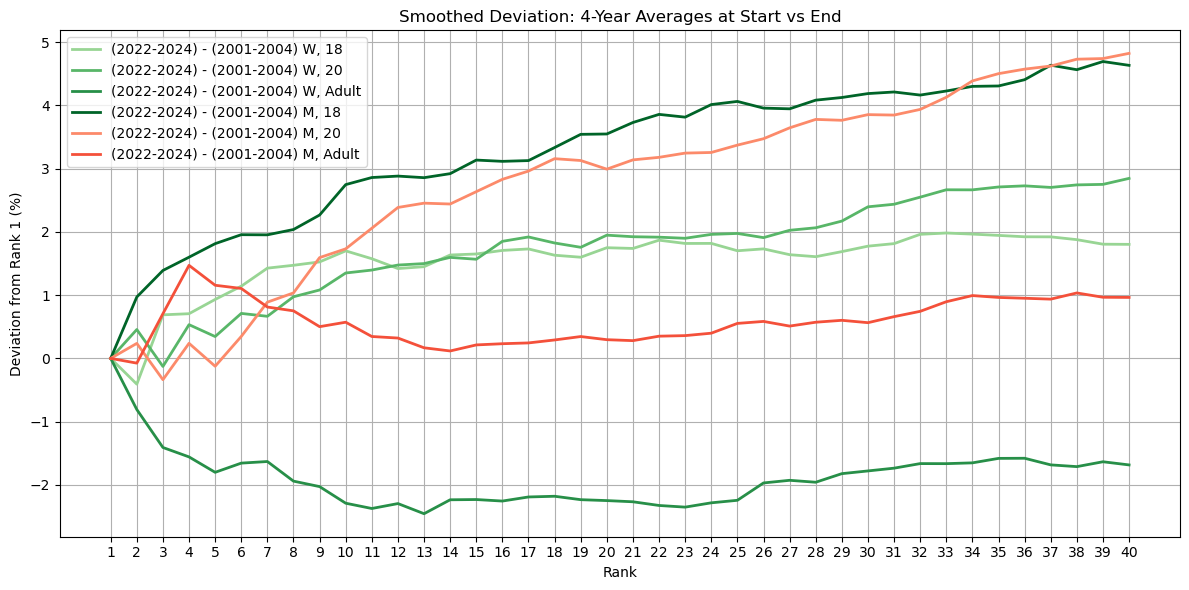

In [30]:
import itertools

genders = ['W', 'M']
age_groups = ['18', '20', 'Adult']

age_colors = {
    '18': 'blue',
    '20': 'orange',
    'U23': 'green',
    'Adult': 'red'
}

diff = []

# 8 different colours for the 8 lines
men_colors   = [plt.cm.Greens(i) for i in np.linspace(0.4, 0.9, 4)]
women_colors = [plt.cm.Reds(i)   for i in np.linspace(0.4, 0.9, 4)]
color_map = {f"{g}-{a}": c for (g,a), c in zip(itertools.product(genders, age_groups), itertools.chain(men_colors, women_colors))}

plt.figure(figsize=(12,6))


for gender in genders:

    for age in age_groups:

        # Fix adult naming
        if age == "Adult":
            age_filter = "Frauen" if gender == "W" else "Maenner"
        else:
            age_filter = age
        
        top_n = 40
        years = sorted(data['jahr'].unique())

        base_group = data[(data["geschlecht"] == gender) &(data["altersklasse"] == age_filter)]

        base_group = hp.collect_top_entries(base_group, top_n)

        # 1. Collect normalized scores per rank per subgroup
        S_rel_gr_list = {r: [] for r in range(1, top_n+1)}

        for (disc, gender, age_filter), subdata in base_group.groupby(["disziplin","geschlecht","altersklasse"]):
            S_g = subdata.groupby("jahr")["iaaf_score"].apply(
                lambda x: x.sort_values(ascending=False).head(top_n).values
            )
            
            if 2001 not in S_g.index:
                continue

            S_gr = pd.DataFrame({year: vals for year, vals in zip(S_g.index, S_g.values)}).T
            S_gr.columns = range(1, top_n+1)
            S_gr.index.name = "jahr"

            diff_1_r = (S_gr[1].values[:, None] - S_gr) / S_gr[1].values[:, None] * 100
            diff_1_r[1] = 0

            # Store per rank
            for r in range(1, top_n+1):
                S_rel_gr_list[r].append(diff_1_r[r])


        # Compute mean per rank across subgroups
        mu_r = pd.DataFrame({r: pd.concat(series, axis=1).mean(axis=1) 
                                        for r, series in S_rel_gr_list.items()})
        mu_r = mu_r.sort_index()

        
        # Compute mean for rank 30 for the two periods
        mean_2001_2004_r30 = mu_r.loc[2001:2004, 30].mean()
        mean_2022_2024_r30 = mu_r.loc[2022:2024, 30].mean()

        #Compute mean for all ranks for the two periods
        mean_2001_2004 = mu_r.loc[2001:2004].mean()
        mean_2022_2024 = mu_r.loc[2022:2024].mean()

        diff_r = mean_2022_2024 - mean_2001_2004

 
        # Difference
        diff_r30 = mean_2022_2024_r30 - mean_2001_2004_r30

        # Append to list
        diff.append([gender, age, diff_r30])

        # Plot Difference for all ranks 2001-2004 vs 2022-2024
        key = f"{gender}-{age}"
        plt.plot(ranks, diff_r, label=f'(2022-2024) - (2001-2004) {gender}, {age}', color=color_map[key], linewidth=2)


df_diff = pd.DataFrame(diff, columns=['Gender', 'Age', 'MeanDiff'])
print(df_diff)


plt.xlabel("Rank")
plt.ylabel("Deviation from Rank 1 (%)")
plt.title("Smoothed Deviation: 4-Year Averages at Start vs End")
plt.xticks(ranks)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

1     1.923827
2     1.330400
3     1.125871
4     0.214130
5     0.277396
6    -0.288567
7    -0.414291
8    -0.382234
9    -0.944855
10   -0.884149
11   -1.066898
12   -1.077517
13   -0.993668
14   -1.171981
15   -1.575579
16   -1.709267
17   -1.637542
18   -1.777544
19   -1.843134
20   -2.020134
21   -2.166463
22   -2.213710
23   -2.320135
24   -2.616098
25   -2.654773
26   -2.633097
27   -2.664853
28   -2.728490
29   -2.780424
30   -2.897426
31   -3.049549
32   -3.082502
33   -3.284278
34   -3.369937
35   -3.358845
36   -3.402093
37   -3.519235
38   -3.537044
39   -3.783977
40   -3.775485
dtype: float64


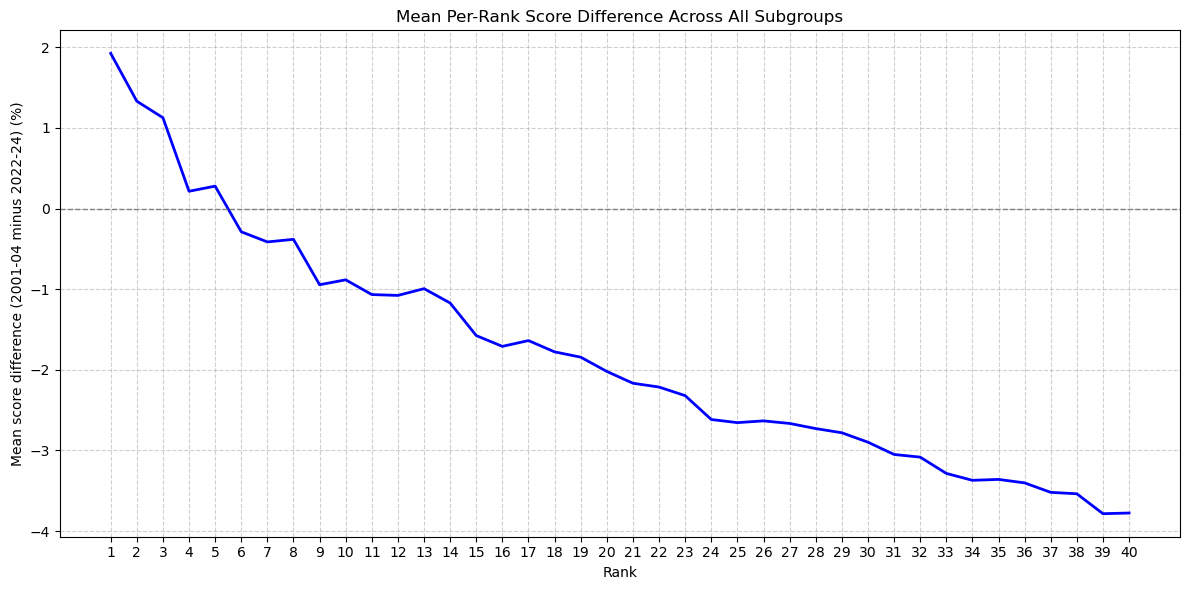

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

top_n = 40
ranks = range(1, top_n + 1)

# Store differences per subgroup
diff_subgroups = []

# Loop over subgroups
for (disc, gender, age), subdata in top_raw.groupby(["disziplin","geschlecht","altersklasse"]):
    
    S_g = subdata.groupby("jahr")["iaaf_score"].apply(
        lambda x: x.sort_values(ascending=False).head(top_n).values
    )
    
    if 2001 not in S_g.index:
        continue

    # Collect scores per rank
    S_gr_list = {r: [] for r in range(1, top_n+1)}
    S_gr = pd.DataFrame({year: vals for year, vals in zip(S_g.index, S_g.values)}).T
    S_gr.columns = range(1, top_n+1)
    S_gr.index.name = "jahr"

    for r in range(1, top_n+1):
        S_gr_list[r].append(S_gr[r])

    # Mean per rank for this subgroup
    mu_r = pd.DataFrame({r: pd.concat(series, axis=1).mean(axis=1)
                         for r, series in S_gr_list.items()})
    mu_r = mu_r.sort_index()

    # Compute difference per rank
    start_avg = mu_r.loc[2001:2004].mean()
    end_avg   = mu_r.loc[2021:2024].mean()
    diff_avg  = (end_avg - start_avg) / start_avg * 100

    diff_subgroups.append(diff_avg)


# Compute mean of differences across all subgroups
mean_diff = pd.DataFrame(diff_subgroups).mean(axis=0)

print(mean_diff)

# Plot mean difference per rank
plt.figure(figsize=(12,6))
plt.plot(ranks, mean_diff, color='blue', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.xlabel("Rank")
plt.ylabel("Mean score difference (2001-04 minus 2022-24) (%)")
plt.title("Mean Per-Rank Score Difference Across All Subgroups")
plt.xticks(ranks)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Lite

Empty DataFrame
Columns: [Gender, Age, MeanDiff]
Index: []


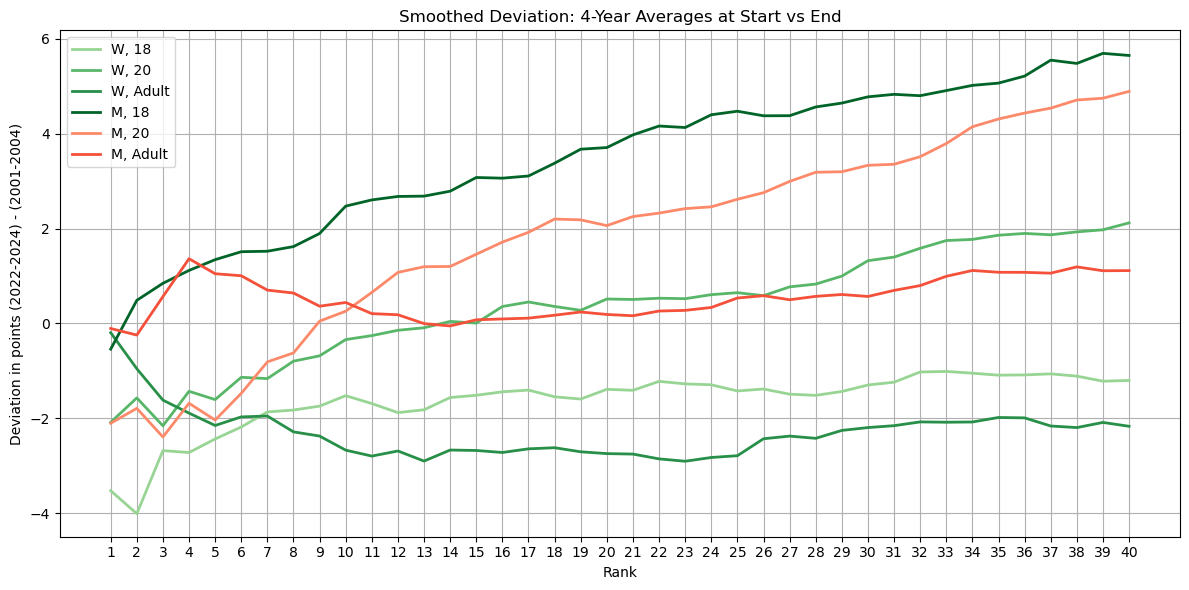

In [33]:
import itertools

genders = ['W', 'M']
age_groups = ['18', '20', 'Adult']

age_colors = {
    '18': 'blue',
    '20': 'orange',
    'U23': 'green',
    'Adult': 'red'
}

diff = []

# 8 different colours for the 8 lines
men_colors   = [plt.cm.Greens(i) for i in np.linspace(0.4, 0.9, 4)]
women_colors = [plt.cm.Reds(i)   for i in np.linspace(0.4, 0.9, 4)]
color_map = {f"{g}-{a}": c for (g,a), c in zip(itertools.product(genders, age_groups), itertools.chain(men_colors, women_colors))}

plt.figure(figsize=(12,6))


for gender in genders:

    for age in age_groups:

        # Fix adult naming
        if age == "Adult":
            age_filter = "Frauen" if gender == "W" else "Maenner"
        else:
            age_filter = age
        
        top_n = 40
        years = sorted(data['jahr'].unique())

        base_group = data[(data["geschlecht"] == gender) &(data["altersklasse"] == age_filter)]

        base_group = hp.collect_top_entries(base_group, top_n)

        # 1. Collect normalized scores per rank per subgroup
        diff_subgroups = []

        for (disc, gender, age_filter), subdata in base_group.groupby(["disziplin","geschlecht","altersklasse"]):
            S_g = subdata.groupby("jahr")["iaaf_score"].apply(
                lambda x: x.sort_values(ascending=False).head(top_n).values
            )
            
            if 2001 not in S_g.index:
                continue

            # Collect scores per rank
            S_gr_list = {r: [] for r in range(1, top_n+1)}
            S_gr = pd.DataFrame({year: vals for year, vals in zip(S_g.index, S_g.values)}).T
            S_gr.columns = range(1, top_n+1)
            S_gr.index.name = "jahr"

            for r in range(1, top_n+1):
                S_gr_list[r].append(S_gr[r])

            # Mean per rank for this subgroup
            mu_r = pd.DataFrame({r: pd.concat(series, axis=1).mean(axis=1)
                                for r, series in S_gr_list.items()})
            mu_r = mu_r.sort_index()

            # Compute difference per rank
            start_avg = mu_r.loc[2001:2004].mean()
            end_avg   = mu_r.loc[2022:2024].mean()
            diff_avg  = (start_avg - end_avg) / start_avg * 100

            diff_subgroups.append(diff_avg)


        mean_diff = pd.DataFrame(diff_subgroups).mean(axis=0)

        # Plot Difference for all ranks 2001-2004 vs 2022-2024
        key = f"{gender}-{age}"
        plt.plot(ranks, mean_diff, label=f'{gender}, {age}', color=color_map[key], linewidth=2)

df_diff = pd.DataFrame(diff, columns=['Gender', 'Age', 'MeanDiff'])
print(df_diff)


plt.xlabel("Rank")
plt.ylabel("Deviation in points (2022-2024) - (2001-2004)")
plt.title("Smoothed Deviation: 4-Year Averages at Start vs End")
plt.xticks(ranks)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

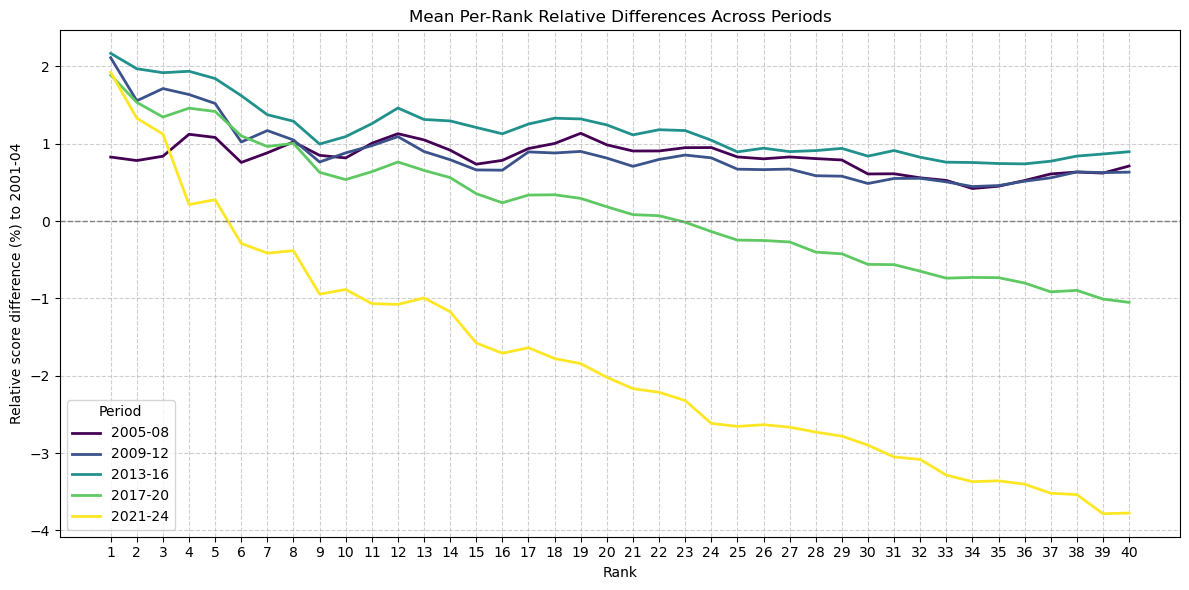

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

top_n = 40
ranks = range(1, top_n + 1)

# Define periods to compare against baseline (as slices)
periods = {
    "2005-08": slice(2005, 2008+1),
    "2009-12": slice(2009, 2012+1),
    "2013-16": slice(2013, 2016+1),
    "2017-20": slice(2017, 2020+1),
    "2021-24": slice(2021, 2024+1)
}

# Store relative differences per period
diff_periods = {key: [] for key in periods.keys()}

# Loop over subgroups
for (disc, gender, age), subdata in top_raw.groupby(["disziplin","geschlecht","altersklasse"]):

    S_g = subdata.groupby("jahr")["iaaf_score"].apply(
        lambda x: x.sort_values(ascending=False).head(top_n).values
    )

    if 2001 not in S_g.index:
        continue

    # Collect scores per rank
    S_gr_list = {r: [] for r in range(1, top_n+1)}
    S_gr = pd.DataFrame({year: vals for year, vals in zip(S_g.index, S_g.values)}).T
    S_gr.columns = range(1, top_n+1)
    S_gr.index.name = "jahr"

    for r in range(1, top_n+1):
        S_gr_list[r].append(S_gr[r])

    # Mean per rank for this subgroup
    mu_r = pd.DataFrame({r: pd.concat(series, axis=1).mean(axis=1)
                         for r, series in S_gr_list.items()})
    mu_r = mu_r.sort_index()

    # Baseline: 2001-04
    baseline = mu_r.loc[2001:2004].mean()

    # Compute relative differences for all periods
    for key, yrs in periods.items():
        period_avg = mu_r.loc[yrs].mean()
        diff_rel = (period_avg - baseline) / baseline * 100
        diff_periods[key].append(diff_rel)

# Compute mean across subgroups for each period
mean_diff_periods = {key: pd.DataFrame(diff_periods[key]).mean(axis=0) for key in periods.keys()}

# Plot all periods
plt.figure(figsize=(12,6))
colors = plt.cm.viridis(np.linspace(0,1,len(periods)))

for color, (key, diff) in zip(colors, mean_diff_periods.items()):
    plt.plot(ranks, diff, color=color, linewidth=2, label=key)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Rank")
plt.ylabel("Relative score difference (%) to 2001-04")
plt.title("Mean Per-Rank Relative Differences Across Periods")
plt.xticks(ranks)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Period")
plt.tight_layout()
plt.show()


In [38]:
results = []

top_n = 40
ranks = range(1, top_n + 1)
years = sorted(data['jahr'].unique())

for gender in genders:
    for age in age_groups:

        # Fix adult naming
        age_filter = "Frauen" if (gender == "W" and age == "Adult") else \
                     "Maenner" if (gender == "M" and age == "Adult") else age

        base_group = data[
            (data["geschlecht"] == gender) &
            (data["altersklasse"] == age_filter)
        ]

        base_group = hp.collect_top_entries(base_group, top_n)

        for (disc, g, a), subdata in base_group.groupby(
            ["disziplin", "geschlecht", "altersklasse"]
        ):

            S_g = subdata.groupby("jahr")["iaaf_score"].apply(
                lambda x: x.sort_values(ascending=False).head(top_n).values
            )

            if 2001 not in S_g.index:
                continue

            S_gr = pd.DataFrame(
                {year: vals for year, vals in zip(S_g.index, S_g.values)}
            ).T
            S_gr.columns = ranks

            start_avg = S_gr.loc[2001:2004].mean()
            end_avg   = S_gr.loc[2022:2024].mean()

            diff_avg = (start_avg - end_avg) / start_avg * 100

            for r, val in diff_avg.items():
                results.append({
                    "Gender": gender,
                    "Discipline": disc,
                    "Age": age,
                    "Rank": r,
                    "Diff": val
                })

df = pd.DataFrame(results)


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Lite

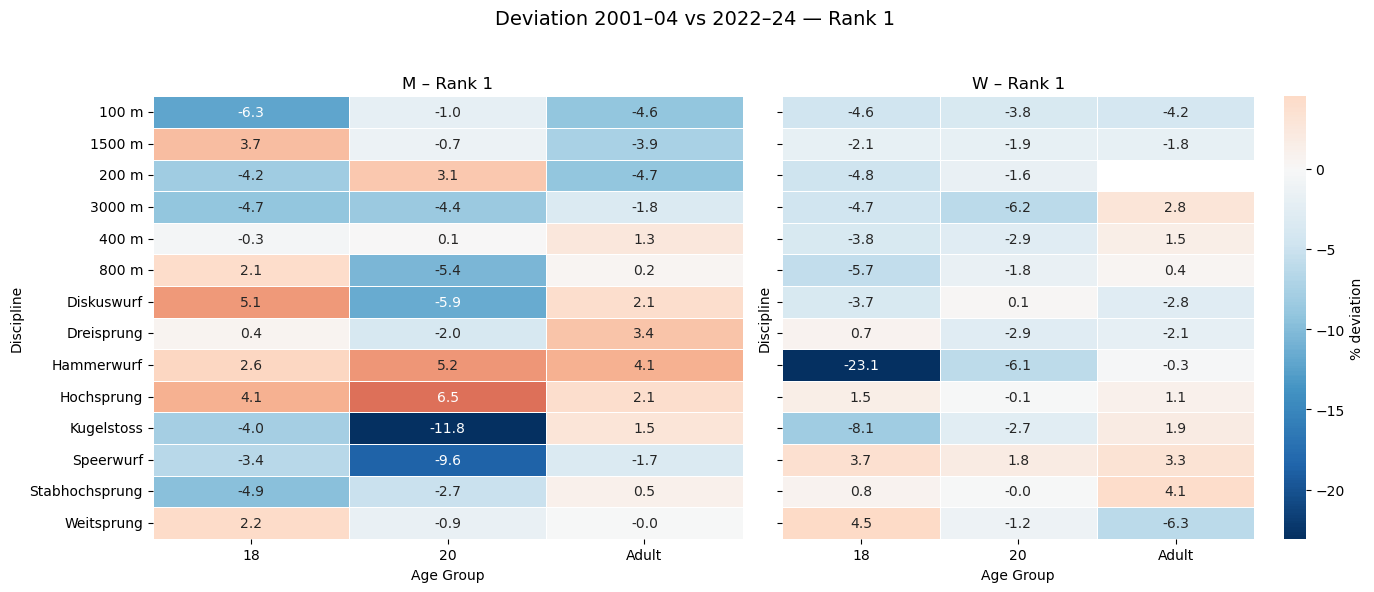

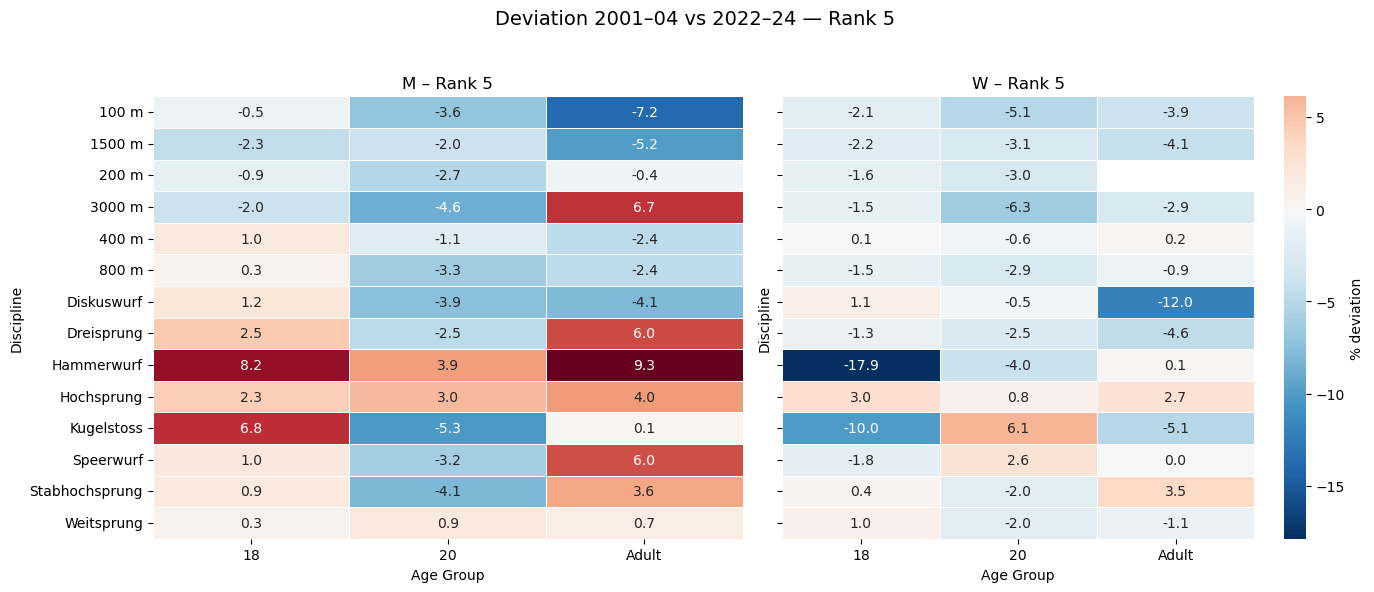

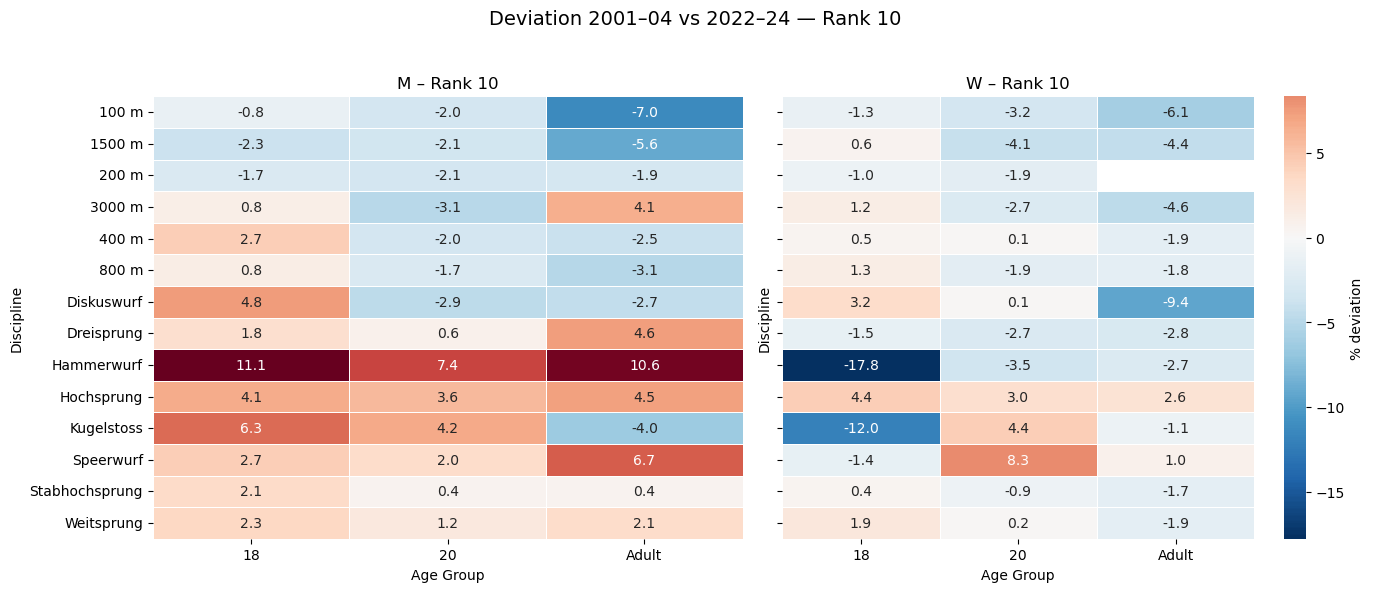

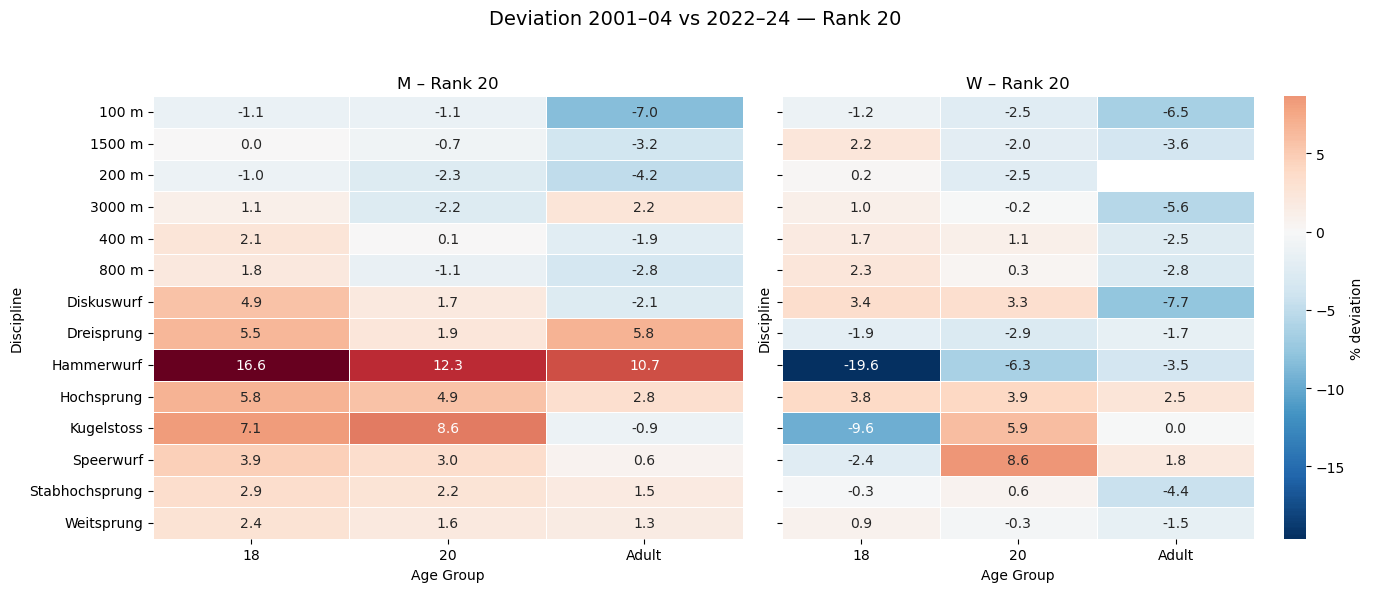

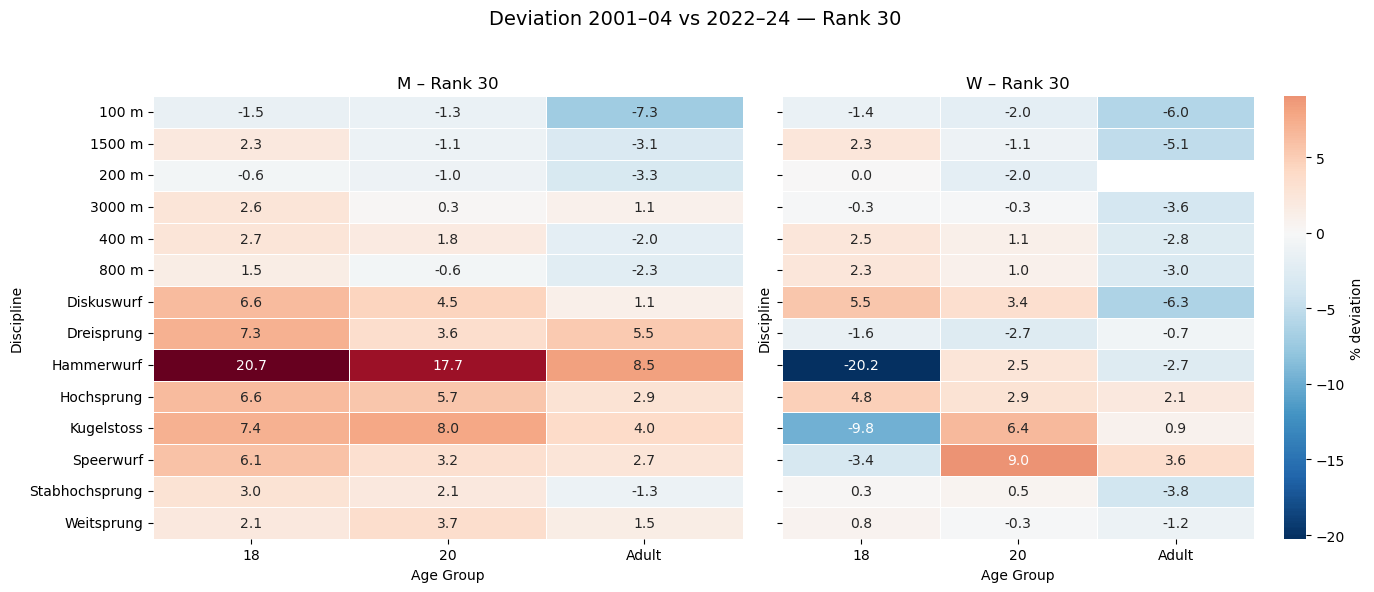

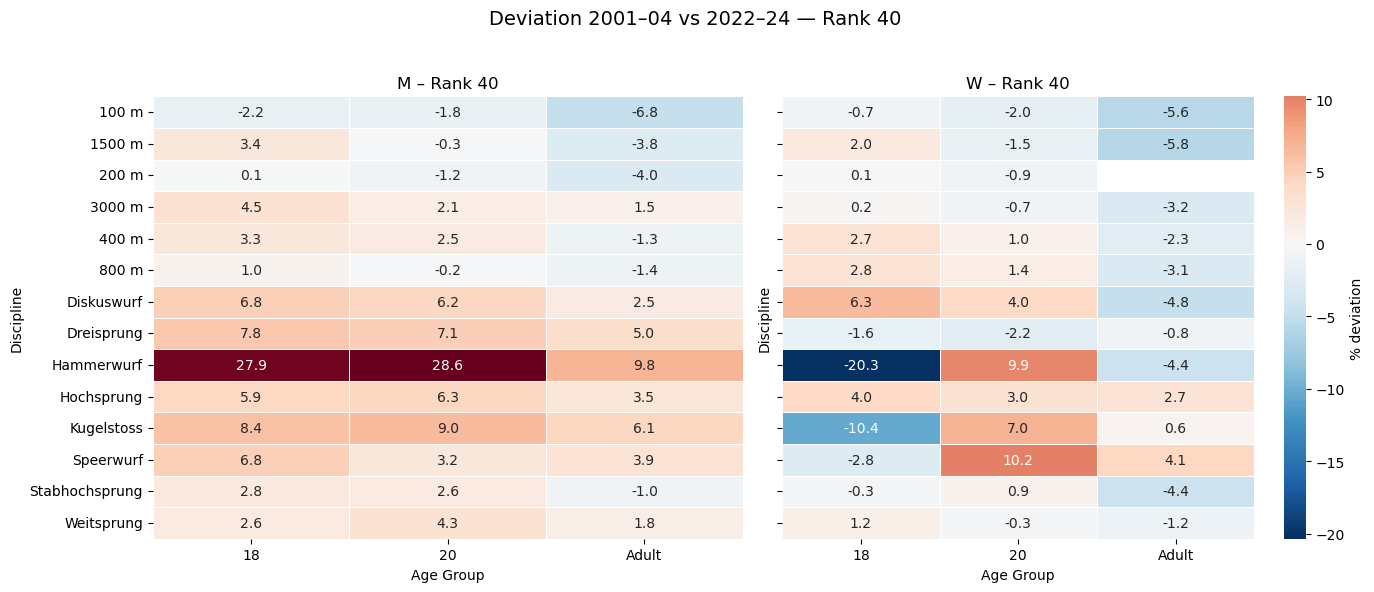

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_ranks = [1, 5, 10, 20, 30, 40]

for r in selected_ranks:

    fig, axes = plt.subplots(
        nrows=1, ncols=2,
        figsize=(14, 6),
        sharey=True
    )

    for ax, gender in zip(axes, ["M", "W"]):

        subset = df[
            (df["Rank"] == r) &
            (df["Gender"] == gender)
        ]

        if subset.empty:
            ax.set_visible(False)
            continue

        heatmap_data = subset.pivot(
            index="Discipline",
            columns="Age",
            values="Diff"
        ).reindex(columns=age_groups)

        sns.heatmap(
            heatmap_data,
            ax=ax,
            cmap="RdBu_r",
            center=0,
            annot=True,
            fmt=".1f",
            linewidths=0.5,
            cbar=(gender == "W"),   # one colorbar per figure
            cbar_kws={"label": "% deviation"}
        )

        ax.set_title(f"{gender} – Rank {r}")
        ax.set_xlabel("Age Group")
        ax.set_ylabel("Discipline")

    fig.suptitle(
        f"Deviation 2001–04 vs 2022–24 — Rank {r}",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [ ]:
plt.figure(figsize=(7, 7))

plt.scatter(
    abs_diff,
    rel_diff,
    s=70,
    alpha=0.8
)

# Reference lines
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Absolute score change (IAAF points)")
plt.ylabel("Relative change vs Rank 1 (%)")

plt.title("Absolute vs Relative Performance Change\n(2022–2024 minus 2001–2004)")

for r in abs_diff.index:
    plt.text(
        abs_diff.loc[r],
        rel_diff.loc[r],
        str(r),
        fontsize=9,
        ha="center",
        va="center"
    )



plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'abs_diff' is not defined

<Figure size 700x700 with 0 Axes>